# Replicate consistency analysis

This notebook analyzes the consistency of Buscar `On-Buscar` and `Off-Buscar` scores across experimental replicates in the CPJUMP1 dataset. It compares matched replicate pairs (`paired`) versus mismatched pairs (`unpaired`) to test whether Buscar captures perturbation-specific morphology across plates.

### Key visualizations
- **Score distribution plots**: Kernel density plots of mean `On-Buscar` and `Off-Buscar` scores per treatment, comparing paired versus unpaired replicate matching conditions, with statistical test annotations.
- **Plate-pair heatmaps**: Per-treatment `ref_plate × compared_plate` matrices of mean `On-Buscar` score, shown for top, middle, and bottom treatments by mean score.

In [32]:
import pathlib
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

PALETTE = {"paired": "#2196F3", "non-paired": "#FF5722"}

In [33]:
data_dir = pathlib.Path("./results/replicate_analysis")

# Load the replicate consistency results for both real and shuffled compound treated
# U20S cell line
u2os_rep_trt_df = pl.read_ndjson(
    data_dir / "U2OS_original_compound-replicate-tracking.jsonl"
)
shuffled_u2os_rep_trt_df = pl.read_ndjson(
    data_dir / "U2OS_shuffled_compound-replicate-tracking.jsonl"
)

# Load the replicate consistency results for both real and shuffled compound treated
# A549 cell lin
a549_rep_trt_df = pl.read_ndjson(
    data_dir / "A549_original_compound-replicate-tracking.jsonl"
)
shuffled_a549_rep_trt_df = pl.read_ndjson(
    data_dir / "A549_shuffled_compound-replicate-tracking.jsonl"
)

# Load the replicate consistency results for both real and shuffled CRISPR-Cas9 treated
# U20S cell line
u2os_rep_crispr_df = pl.read_ndjson(
    data_dir / "U2OS_original_crispr-replicate-tracking.jsonl"
)
shuffled_u2os_rep_crispr_df = pl.read_ndjson(
    data_dir / "U2OS_shuffled_crispr-replicate-tracking.jsonl"
)

# Load the replicate consistency results for both real and shuffled CRISPR-Cas9 treated
# A549 cell line A549
a549_rep_crispr_df = pl.read_ndjson(
    data_dir / "A549_original_crispr-replicate-tracking.jsonl"
)
shuffled_a549_rep_crispr_df = pl.read_ndjson(
    data_dir / "A549_shuffled_crispr-replicate-tracking.jsonl"
)

# output dir
output_dir = pathlib.Path("./results/replicate_analysis")

plot_output = pathlib.Path("./plots/replicate-analysis")
plot_output.mkdir(parents=True, exist_ok=True)

## Score distribution analysis

Compare `On-Buscar` and `Off-Buscar` score distributions between replicate matching conditions (`paired` vs `unpaired`) across treatments.

**Approach:** For each treatment, compute the mean score across iterations and plate comparisons (excluding self-comparisons where `ref_plate_rep == compared_plate_rep`) so each treatment contributes equally to the distribution.

**Caption note:** Statistical annotations use Mann-Whitney U (MWU), Kolmogorov-Smirnov (KS), and Levene tests with Benjamini-Hochberg (BH) correction.

In [34]:
def prepare_cross_data(real_df: pl.DataFrame, shuffled_df: pl.DataFrame):
    """Label, combine, and aggregate per perturbation."""
    real = real_df.with_columns(pl.lit("paired").alias("replicate_matching_condition"))
    shuf = shuffled_df.with_columns(
        pl.lit("non-paired").alias("replicate_matching_condition")
    )
    cross_df = pl.concat([real, shuf])
    agg_df = (
        cross_df.group_by(["replicate_matching_condition", "perturbation"])
        .agg(
            [
                pl.col("on_score").mean().alias("mean_on_buscar_score"),
                pl.col("off_score").mean().alias("mean_off_buscar_score"),
                pl.col("on_score").std().alias("std_on_buscar_score"),
                pl.col("off_score").std().alias("std_off_buscar_score"),
                pl.col("iteration").n_unique().alias("n_iterations"),
            ]
        )
        .sort(["replicate_matching_condition", "perturbation"])
    )
    real_agg = agg_df.filter(
        pl.col("replicate_matching_condition") == "paired"
    ).to_pandas()
    shuf_agg = agg_df.filter(
        pl.col("replicate_matching_condition") == "non-paired"
    ).to_pandas()
    return cross_df, agg_df, real_agg, shuf_agg


def run_statistical_tests(
    real_agg: pd.DataFrame, shuf_agg: pd.DataFrame
) -> pl.DataFrame:
    """Run Mann-Whitney U, KS, and Levene's tests with BH correction."""
    rows = []
    for score_col in ["mean_on_buscar_score", "mean_off_buscar_score"]:
        r, s = real_agg[score_col].dropna(), shuf_agg[score_col].dropna()
        for label, test_res in [
            ("Mann-Whitney U", stats.mannwhitneyu(r, s, alternative="two-sided")),
            ("KS test", stats.ks_2samp(r, s)),
            ("Levene's test", stats.levene(r, s, center="median")),
        ]:
            rows.append(
                {
                    "score": score_col,
                    "test": label,
                    "statistic": test_res.statistic,
                    "p_raw": test_res.pvalue,
                }
            )
    _, p_adj, _, _ = multipletests([r["p_raw"] for r in rows], method="fdr_bh")
    for row, p in zip(rows, p_adj):
        row["p_adj_BH"] = p
    return pl.DataFrame(rows)


PALETTE = {"paired": "#2196F3", "non-paired": "#FF5722"}


def plot_global_distributions(
    real_agg: pd.DataFrame,
    shuf_agg: pd.DataFrame,
    stats_df: pl.DataFrame,
    cell_type: str,
    palette: dict = PALETTE,
    save_path: pathlib.Path | None = None,
):
    """KDE of on-Buscar/off-Buscar score distributions with mean ± SD band and p-value annotation."""

    mw_padj = {
        row["score"]: row["p_adj_BH"]
        for row in stats_df.filter(pl.col("test") == "Mann-Whitney U").iter_rows(
            named=True
        )
    }
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, score_col, title, xlabel in zip(
        axes,
        ["mean_on_buscar_score", "mean_off_buscar_score"],
        [
            "on-Buscar score distribution",
            "off-Buscar score distribution",
        ],
        [
            "Mean on-Buscar score",
            "Mean off-Buscar score",
        ],
    ):
        for label, df in [("paired", real_agg), ("non-paired", shuf_agg)]:
            color = palette[label]
            mean, std = df[score_col].mean(), df[score_col].std()
            sns.kdeplot(
                data=df,
                x=score_col,
                ax=ax,
                label=label,
                color=color,
                fill=True,
                alpha=0.3,
                linewidth=2.5,
            )
            ax.axvline(mean, color=color, linestyle="-", linewidth=2.0, alpha=0.9)
            ax.axvspan(mean - std, mean + std, color=color, alpha=0.08)

        paired_std, non_paired_std = (
            real_agg[score_col].std(),
            shuf_agg[score_col].std(),
        )
        p = mw_padj[score_col]
        p_str = f"p = {p:.2e}" if p >= 1e-300 else "p < 1e-300"
        ax.text(
            0.97,
            0.95,
            f"Mann-Whitney U\n{p_str} (BH-adj)\n─────────────\npaired   SD = {paired_std:.3f}\nnon-paired SD = {non_paired_std:.3f}",
            transform=ax.transAxes,
            fontsize=11.2,
            ha="right",
            va="top",
            family="monospace",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="white",
                edgecolor="gray",
                alpha=0.85,
            ),
        )
        ax.set_title(title, fontsize=16.8, fontweight="bold")
        ax.set_xlabel(xlabel, fontsize=14, fontweight="bold")
        ax.set_ylabel("Density", fontsize=14, fontweight="bold")
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
        ax.tick_params(labelsize=13)

    plt.suptitle(
        f"{cell_type} score distributions",
        fontsize=18.2,
        fontweight="bold",
        y=1.02,
    )

    # Add a single figure-level legend at the bottom
    handles = [
        mpatches.Patch(color=palette[label], label=label, alpha=0.6)
        for label in ["paired", "non-paired"]
    ]
    fig.legend(
        handles=handles,
        title="Replicate matching condition",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.01),
        ncol=2,
        fontsize=13,
        title_fontsize=14,
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_plate_pair_heatmaps(
    real_df: pl.DataFrame,
    shuffled_df: pl.DataFrame,
    agg_df: pl.DataFrame,
    cell_type: str,
    replicate_matching_condition: str = "paired",
    save_path: pathlib.Path | None = None,
):
    """Plate-pair on-Buscar score heatmaps for top / middle / bottom perturbations."""
    source_df = real_df if replicate_matching_condition == "paired" else shuffled_df
    sorted_trts = (
        agg_df.filter(
            pl.col("replicate_matching_condition") == replicate_matching_condition
        )
        .sort("mean_on_buscar_score", descending=True)
        .select(["perturbation", "mean_on_buscar_score"])
        .to_pandas()
    )
    _, mid = len(sorted_trts), len(sorted_trts) // 2
    selected_trts = (
        sorted_trts.iloc[:3]["perturbation"].tolist()
        + sorted_trts.iloc[mid - 1 : mid + 2]["perturbation"].tolist()
        + sorted_trts.iloc[-3:]["perturbation"].tolist()
    )

    fig, axes = plt.subplots(3, 3, figsize=(19, 17))
    for ax, trt in zip(axes.flatten(), selected_trts):
        pivot = (
            source_df.filter(pl.col("perturbation") == trt)
            .group_by(["ref_plate_rep", "compared_plate_rep"])
            .agg(pl.col("on_score").mean())
            .sort(["ref_plate_rep", "compared_plate_rep"])
            .to_pandas()
            .pivot(
                index="ref_plate_rep", columns="compared_plate_rep", values="on_score"
            )
        )
        pivot.index.name = "Reference plate"
        pivot.columns.name = "Compared plate"

        # Per-facet symmetric colorbar centered at 1
        trt_scores = pivot.values.flatten()
        trt_scores = trt_scores[~np.isnan(trt_scores)]
        vcenter = 1.0
        p5 = float(np.percentile(trt_scores, 5))
        p95 = float(np.percentile(trt_scores, 95))
        max_dev = max(abs(p95 - vcenter), abs(vcenter - p5))
        vmin, vmax = vcenter - max_dev, vcenter + max_dev

        mean_score = sorted_trts.loc[
            sorted_trts["perturbation"] == trt, "mean_on_buscar_score"
        ].values[0]
        sns.heatmap(
            pivot,
            ax=ax,
            cmap="coolwarm",
            center=vcenter,
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 20},
            linewidths=0.4,
            cbar_kws={"shrink": 0.8},
        )

        # Draw a darker outline on diagonal cells (same plate vs same plate)
        col_labels = list(pivot.columns)
        for row_i, row_label in enumerate(pivot.index):
            if row_label in col_labels:
                col_j = col_labels.index(row_label)
                ax.add_patch(
                    mpatches.Rectangle(
                        (col_j, row_i),
                        1,
                        1,
                        fill=False,
                        edgecolor="black",
                        linewidth=3,
                        clip_on=False,
                    )
                )

        ax.set_title(f"{trt}\n(mean on-Buscar score = {mean_score:.3f})", fontsize=20)
        ax.set_xlabel("Compared plate", fontsize=13, fontweight="bold")
        ax.set_ylabel("Reference plate", fontsize=13, fontweight="bold")
        ax.tick_params(labelsize=15)

    plt.suptitle(
        f"Plate-pair {cell_type} on-Buscar score heatmaps ({replicate_matching_condition}, mean across iterations)",
        fontsize=18,
        y=1.01,
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

In [35]:
u2os_cross_df, u2os_agg_df, u2os_real_agg, u2os_shuf_agg = prepare_cross_data(
    u2os_rep_trt_df, shuffled_u2os_rep_trt_df
)
print(
    f"Treatments (paired):     {u2os_agg_df.filter(pl.col('replicate_matching_condition') == 'paired').height}"
)
print(
    f"Treatments (non-paired): {u2os_agg_df.filter(pl.col('replicate_matching_condition') == 'non-paired').height}"
)

Treatments (paired):     302
Treatments (non-paired): 302


In [36]:
a549_cross_df, a549_agg_df, a549_real_agg, a549_shuf_agg = prepare_cross_data(
    a549_rep_trt_df, shuffled_a549_rep_trt_df
)
print(
    f"Treatments (paired):     {a549_agg_df.filter(pl.col('replicate_matching_condition') == 'paired').height}"
)
print(
    f"Treatments (non-paired): {a549_agg_df.filter(pl.col('replicate_matching_condition') == 'non-paired').height}"
)

Treatments (paired):     302
Treatments (non-paired): 302


In [37]:
u2os_stats_df = run_statistical_tests(u2os_real_agg, u2os_shuf_agg)

# save stats table
u2os_stats_df.write_csv(output_dir / "u2os_statistical_tests.csv", separator=",")

# Display the stats table
u2os_stats_df

score,test,statistic,p_raw,p_adj_BH
str,str,f64,f64,f64
"""mean_on_buscar_score""","""Mann-Whitney U""",3687.0,4.4131e-85,8.8263e-85
"""mean_on_buscar_score""","""KS test""",0.804636,4.3132e-98,2.5879e-97
"""mean_on_buscar_score""","""Levene's test""",353.964292,1.8711e-62,2.8066e-62
"""mean_off_buscar_score""","""Mann-Whitney U""",11689.0,2.4569e-56,2.9483e-56
"""mean_off_buscar_score""","""KS test""",0.784768,1.8488e-92,5.5463e-92
"""mean_off_buscar_score""","""Levene's test""",5.737739,0.016909,0.016909


In [38]:
a549_stats_df = run_statistical_tests(a549_real_agg, a549_shuf_agg)

# save stats table
a549_stats_df.write_csv(output_dir / "a549_statistical_tests.csv", separator=",")

a549_stats_df

score,test,statistic,p_raw,p_adj_BH
str,str,f64,f64,f64
"""mean_on_buscar_score""","""Mann-Whitney U""",1182.0,2.5504e-95,7.6511e-95
"""mean_on_buscar_score""","""KS test""",0.887417,4.3824e-125,2.6295e-124
"""mean_on_buscar_score""","""Levene's test""",89.350713,7.2588e-20,8.7106e-20
"""mean_off_buscar_score""","""Mann-Whitney U""",7711.0,7.1408e-70,1.0711e-69
"""mean_off_buscar_score""","""KS test""",0.788079,2.2254e-93,4.4507e-93
"""mean_off_buscar_score""","""Levene's test""",19.888039,0.00001,0.00001


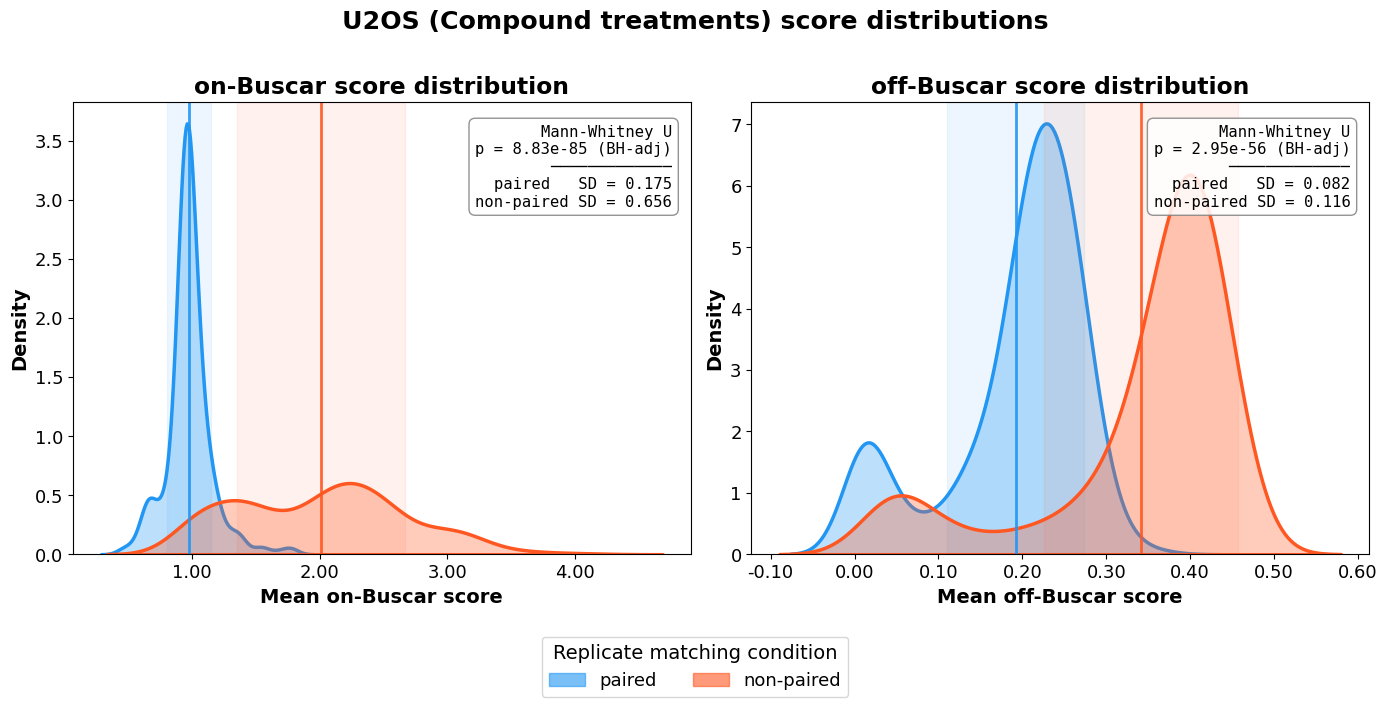

In [39]:
plot_global_distributions(
    u2os_real_agg,
    u2os_shuf_agg,
    u2os_stats_df,
    cell_type="U2OS (Compound treatments)",
    save_path=plot_output / "compound_u2os_global_score_distributions.png",
)

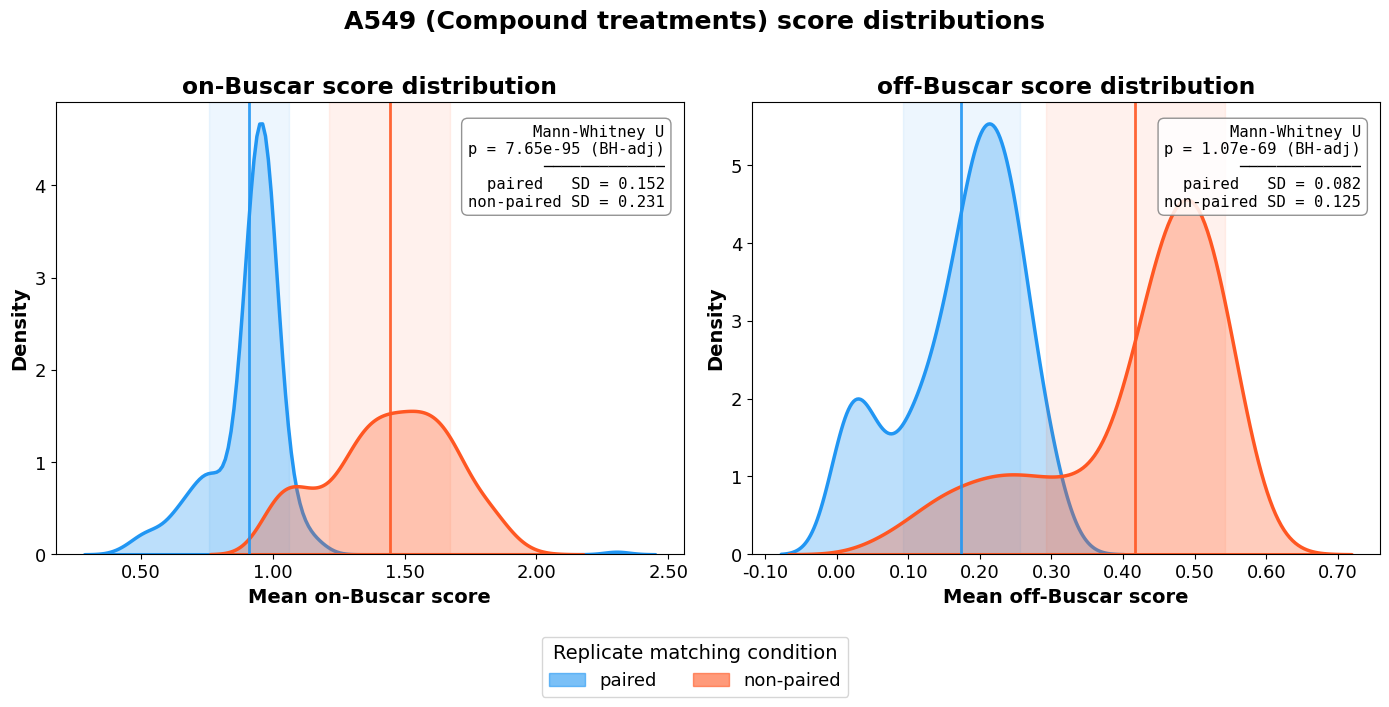

In [40]:
plot_global_distributions(
    a549_real_agg,
    a549_shuf_agg,
    a549_stats_df,
    cell_type="A549 (Compound treatments)",
    save_path=plot_output / "compound_a549_global_score_distributions.png",
)

## Analysis 2: Plate-pair score heatmaps

For selected treatments, build a `ref_plate × compared_plate` matrix of mean `On-Buscar` score (averaged across iterations). Uniform matrices indicate stable replicate behavior across plate pairings, while row/column outliers indicate plate-specific effects.

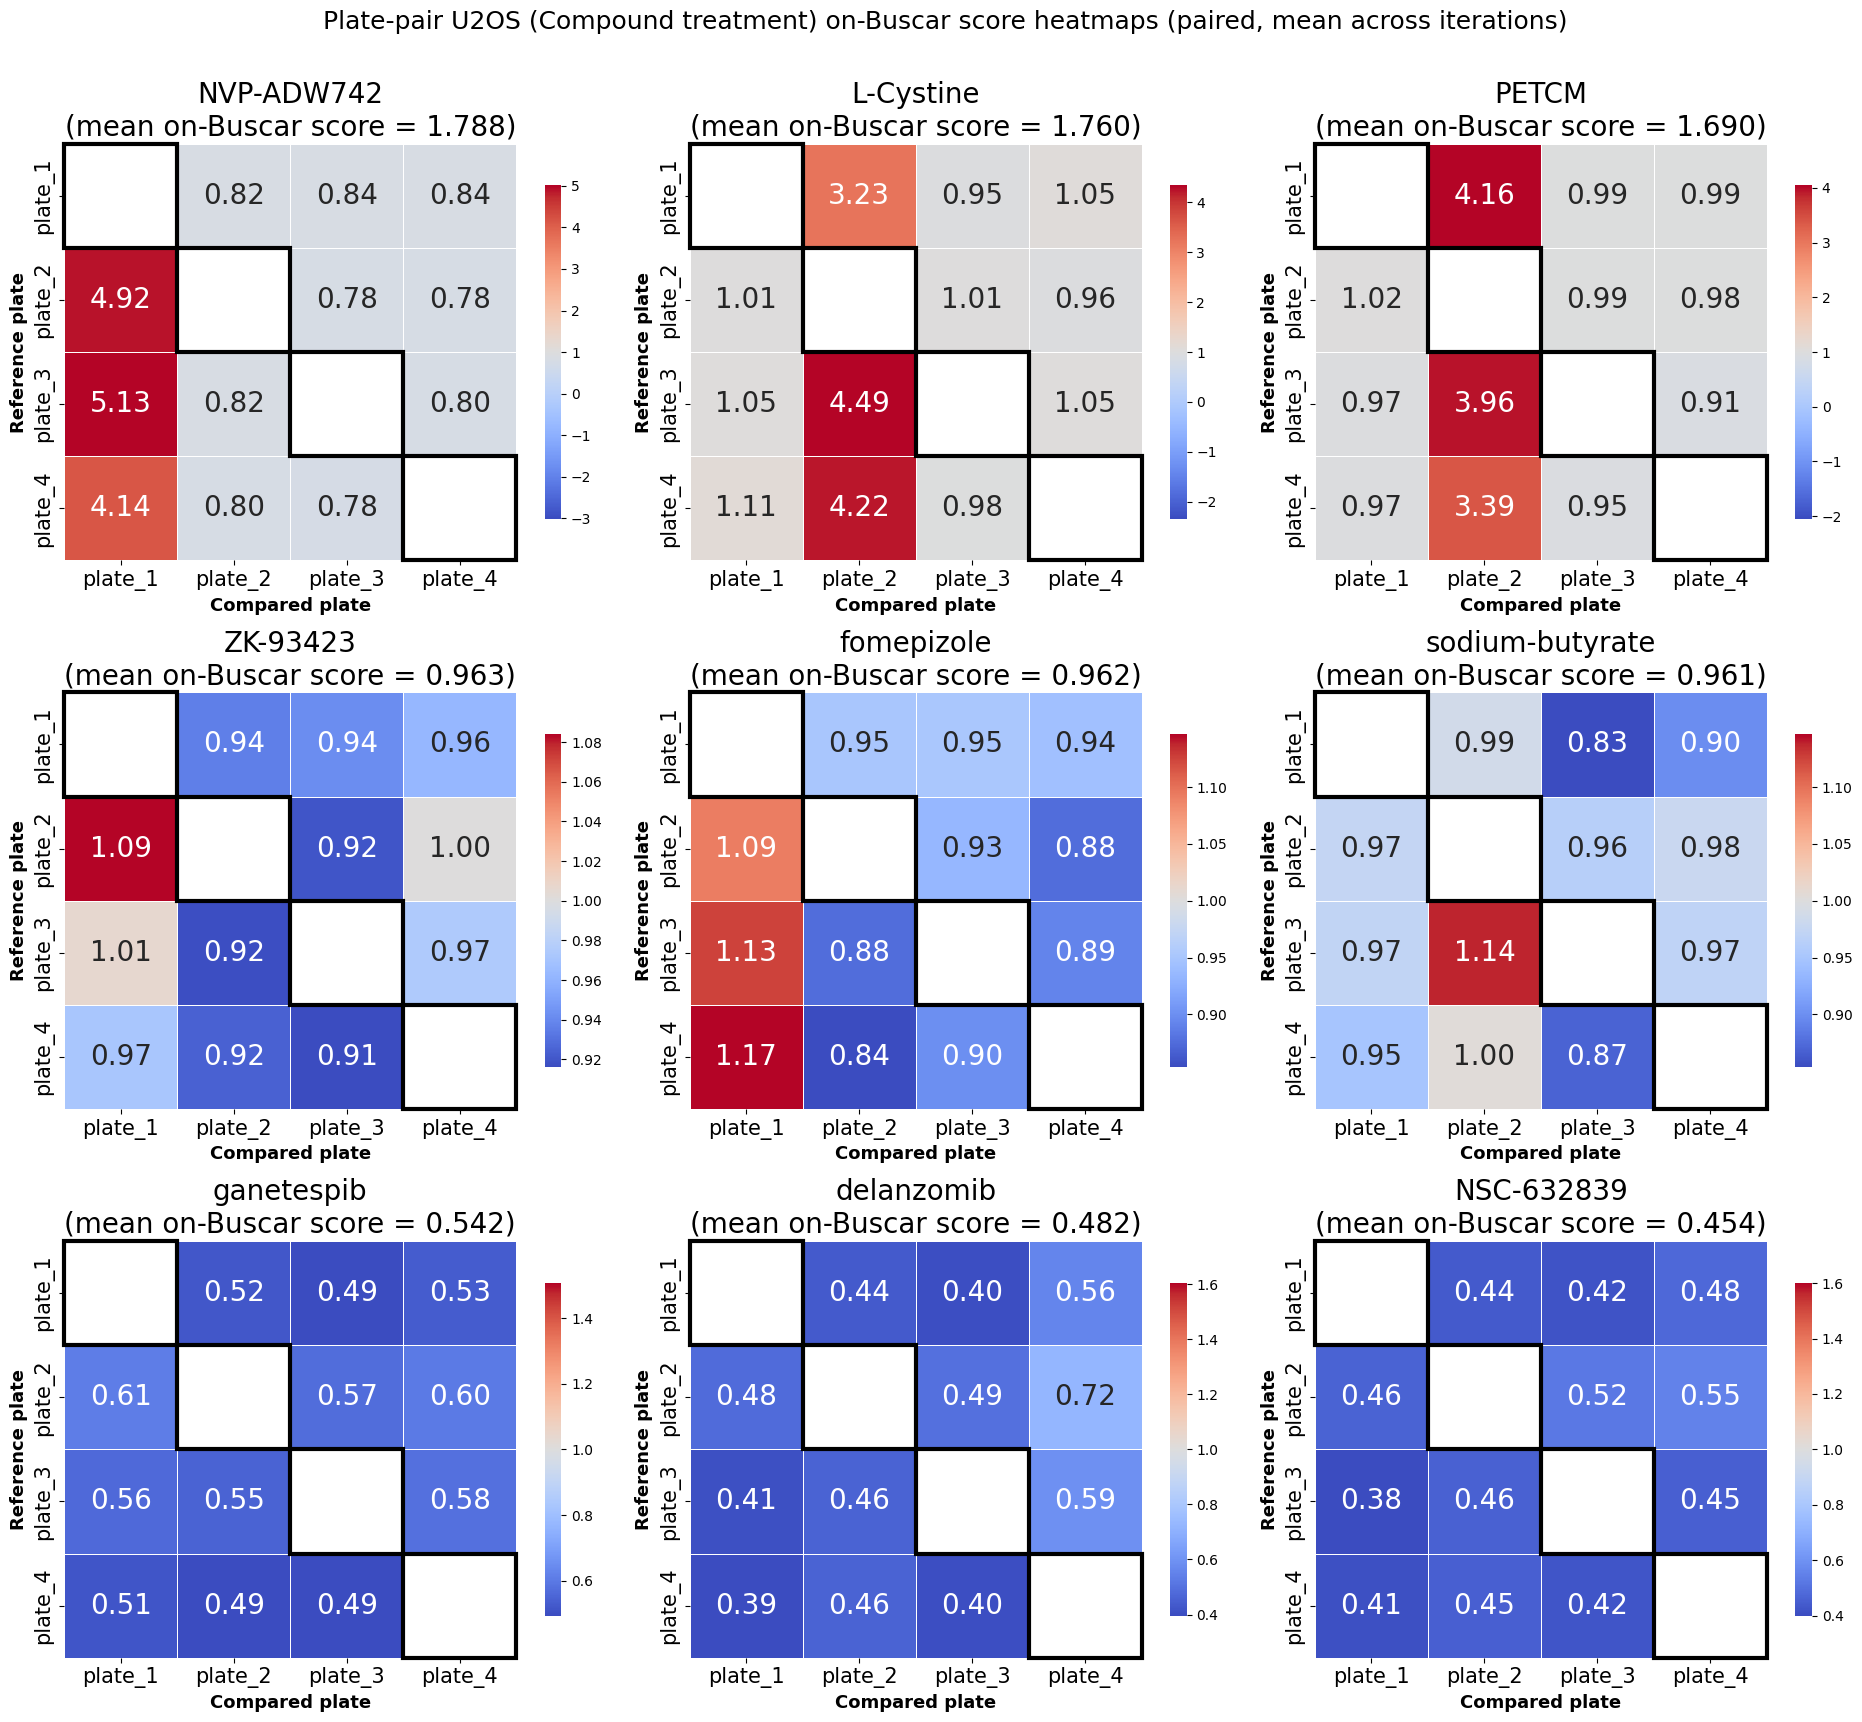

In [41]:
plot_plate_pair_heatmaps(
    u2os_rep_trt_df,
    shuffled_u2os_rep_trt_df,
    u2os_agg_df,
    cell_type="U2OS (Compound treatment)",
    replicate_matching_condition="paired",
    save_path=plot_output / "compound_u2os_plate_pair_heatmaps_real.png",
)

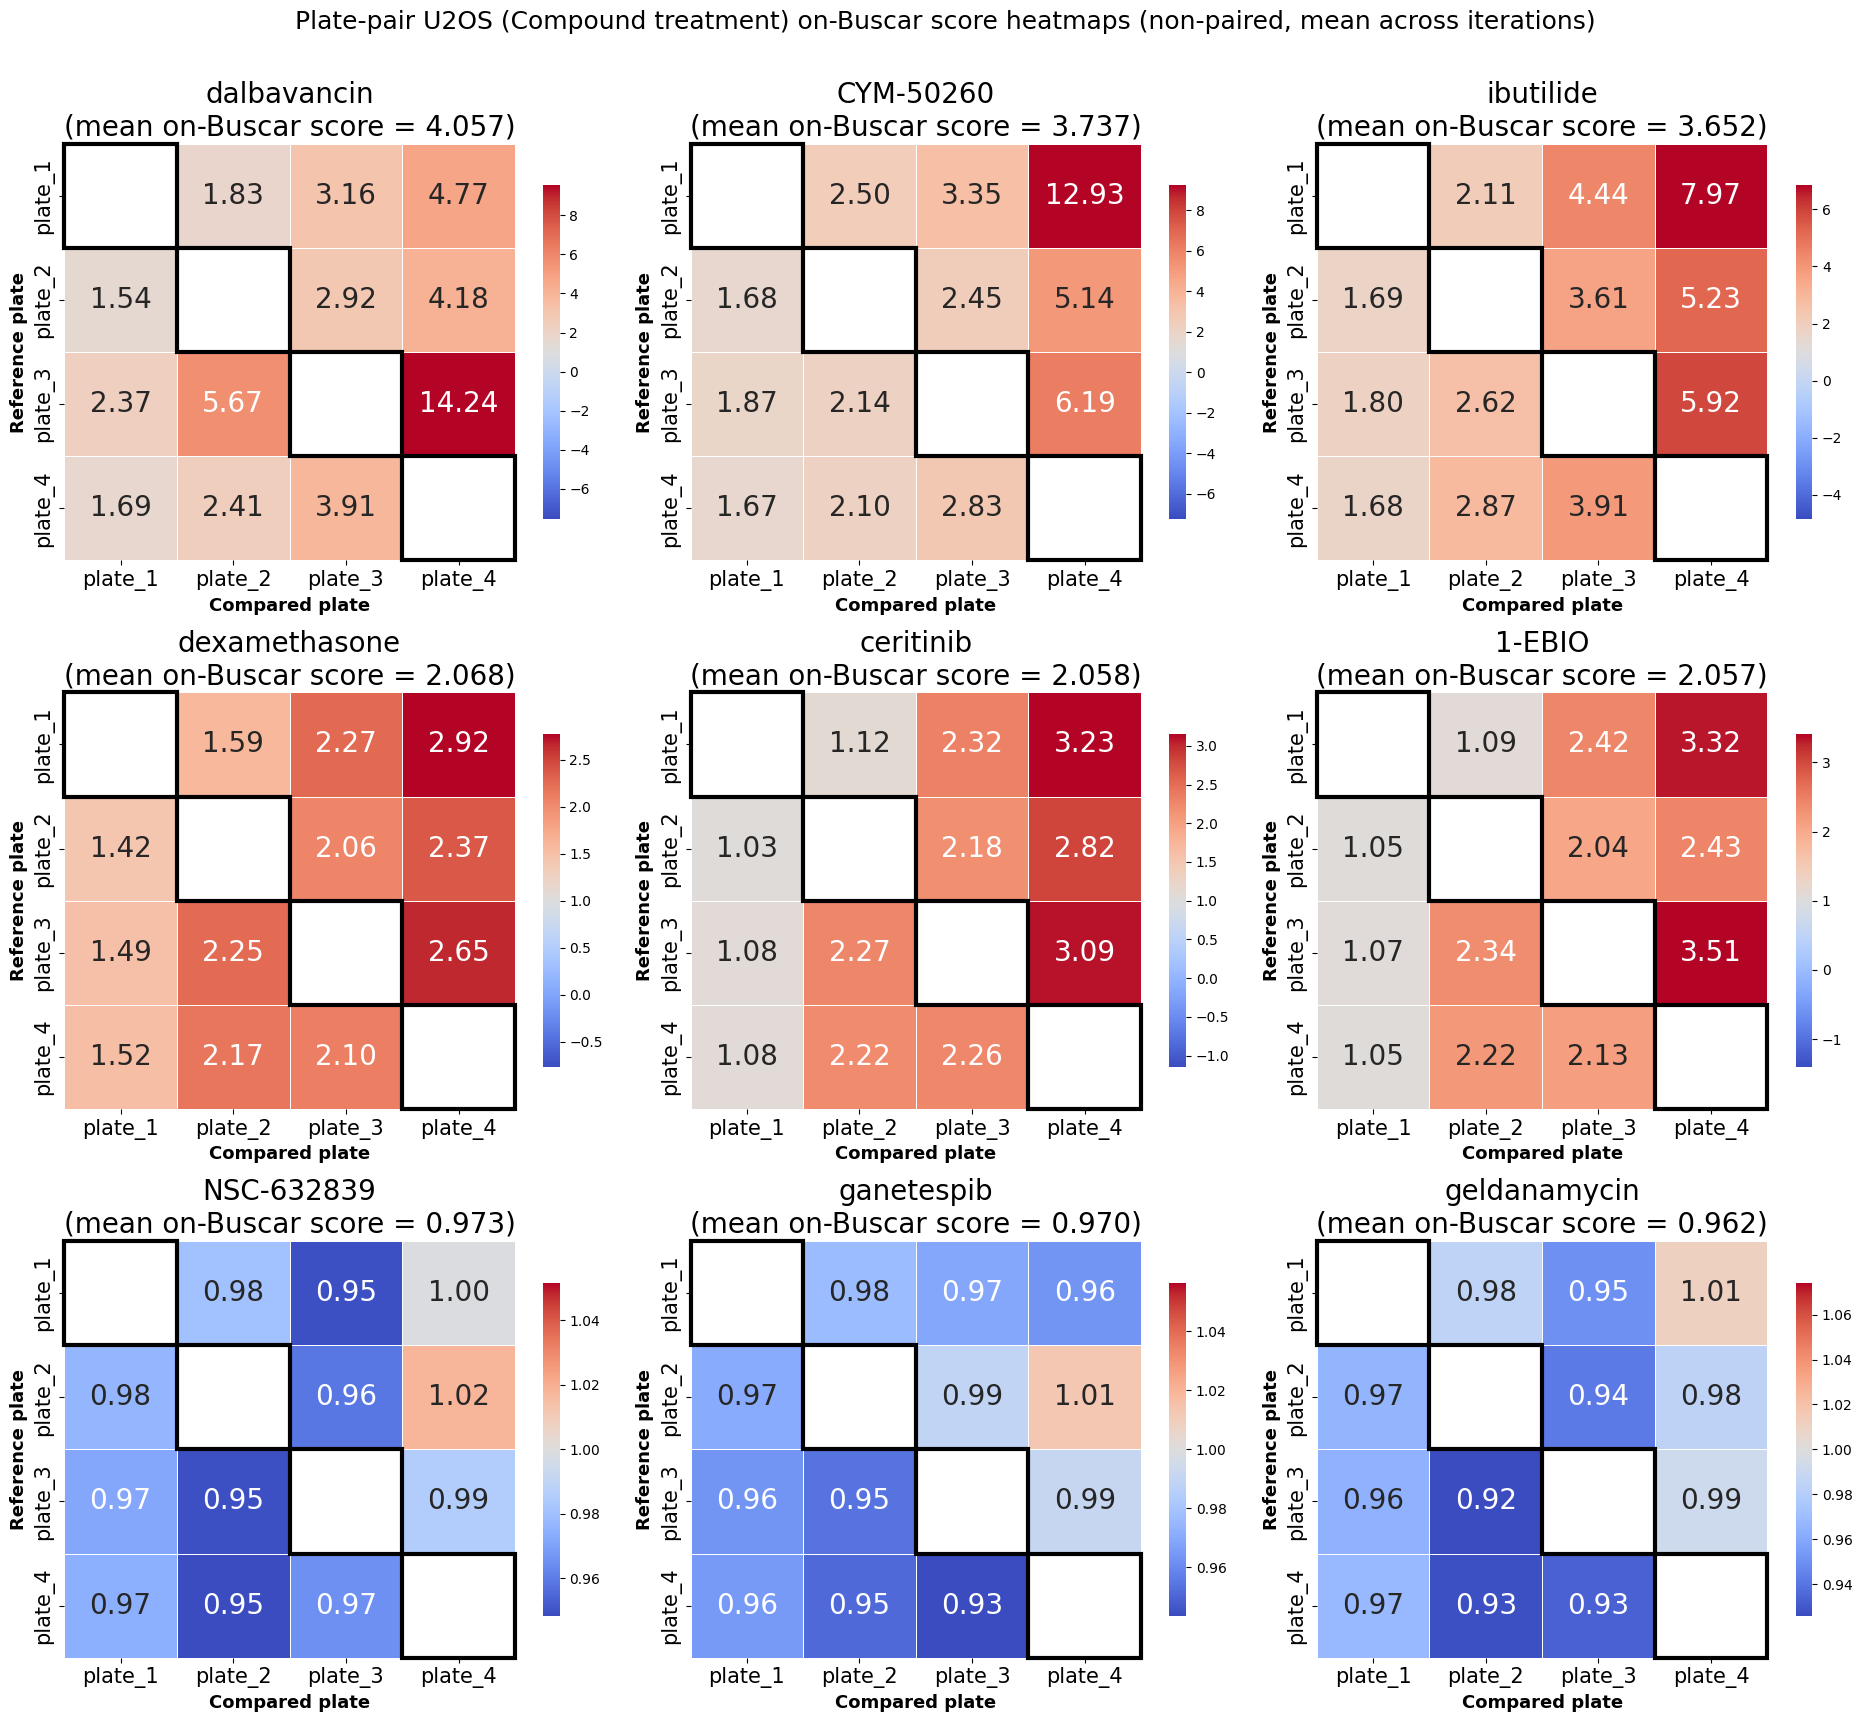

In [42]:
plot_plate_pair_heatmaps(
    u2os_rep_trt_df,
    shuffled_u2os_rep_trt_df,
    u2os_agg_df,
    cell_type="U2OS (Compound treatment)",
    replicate_matching_condition="non-paired",
    save_path=plot_output / "compound_u2os_plate_pair_heatmaps_non_rep.png",
)

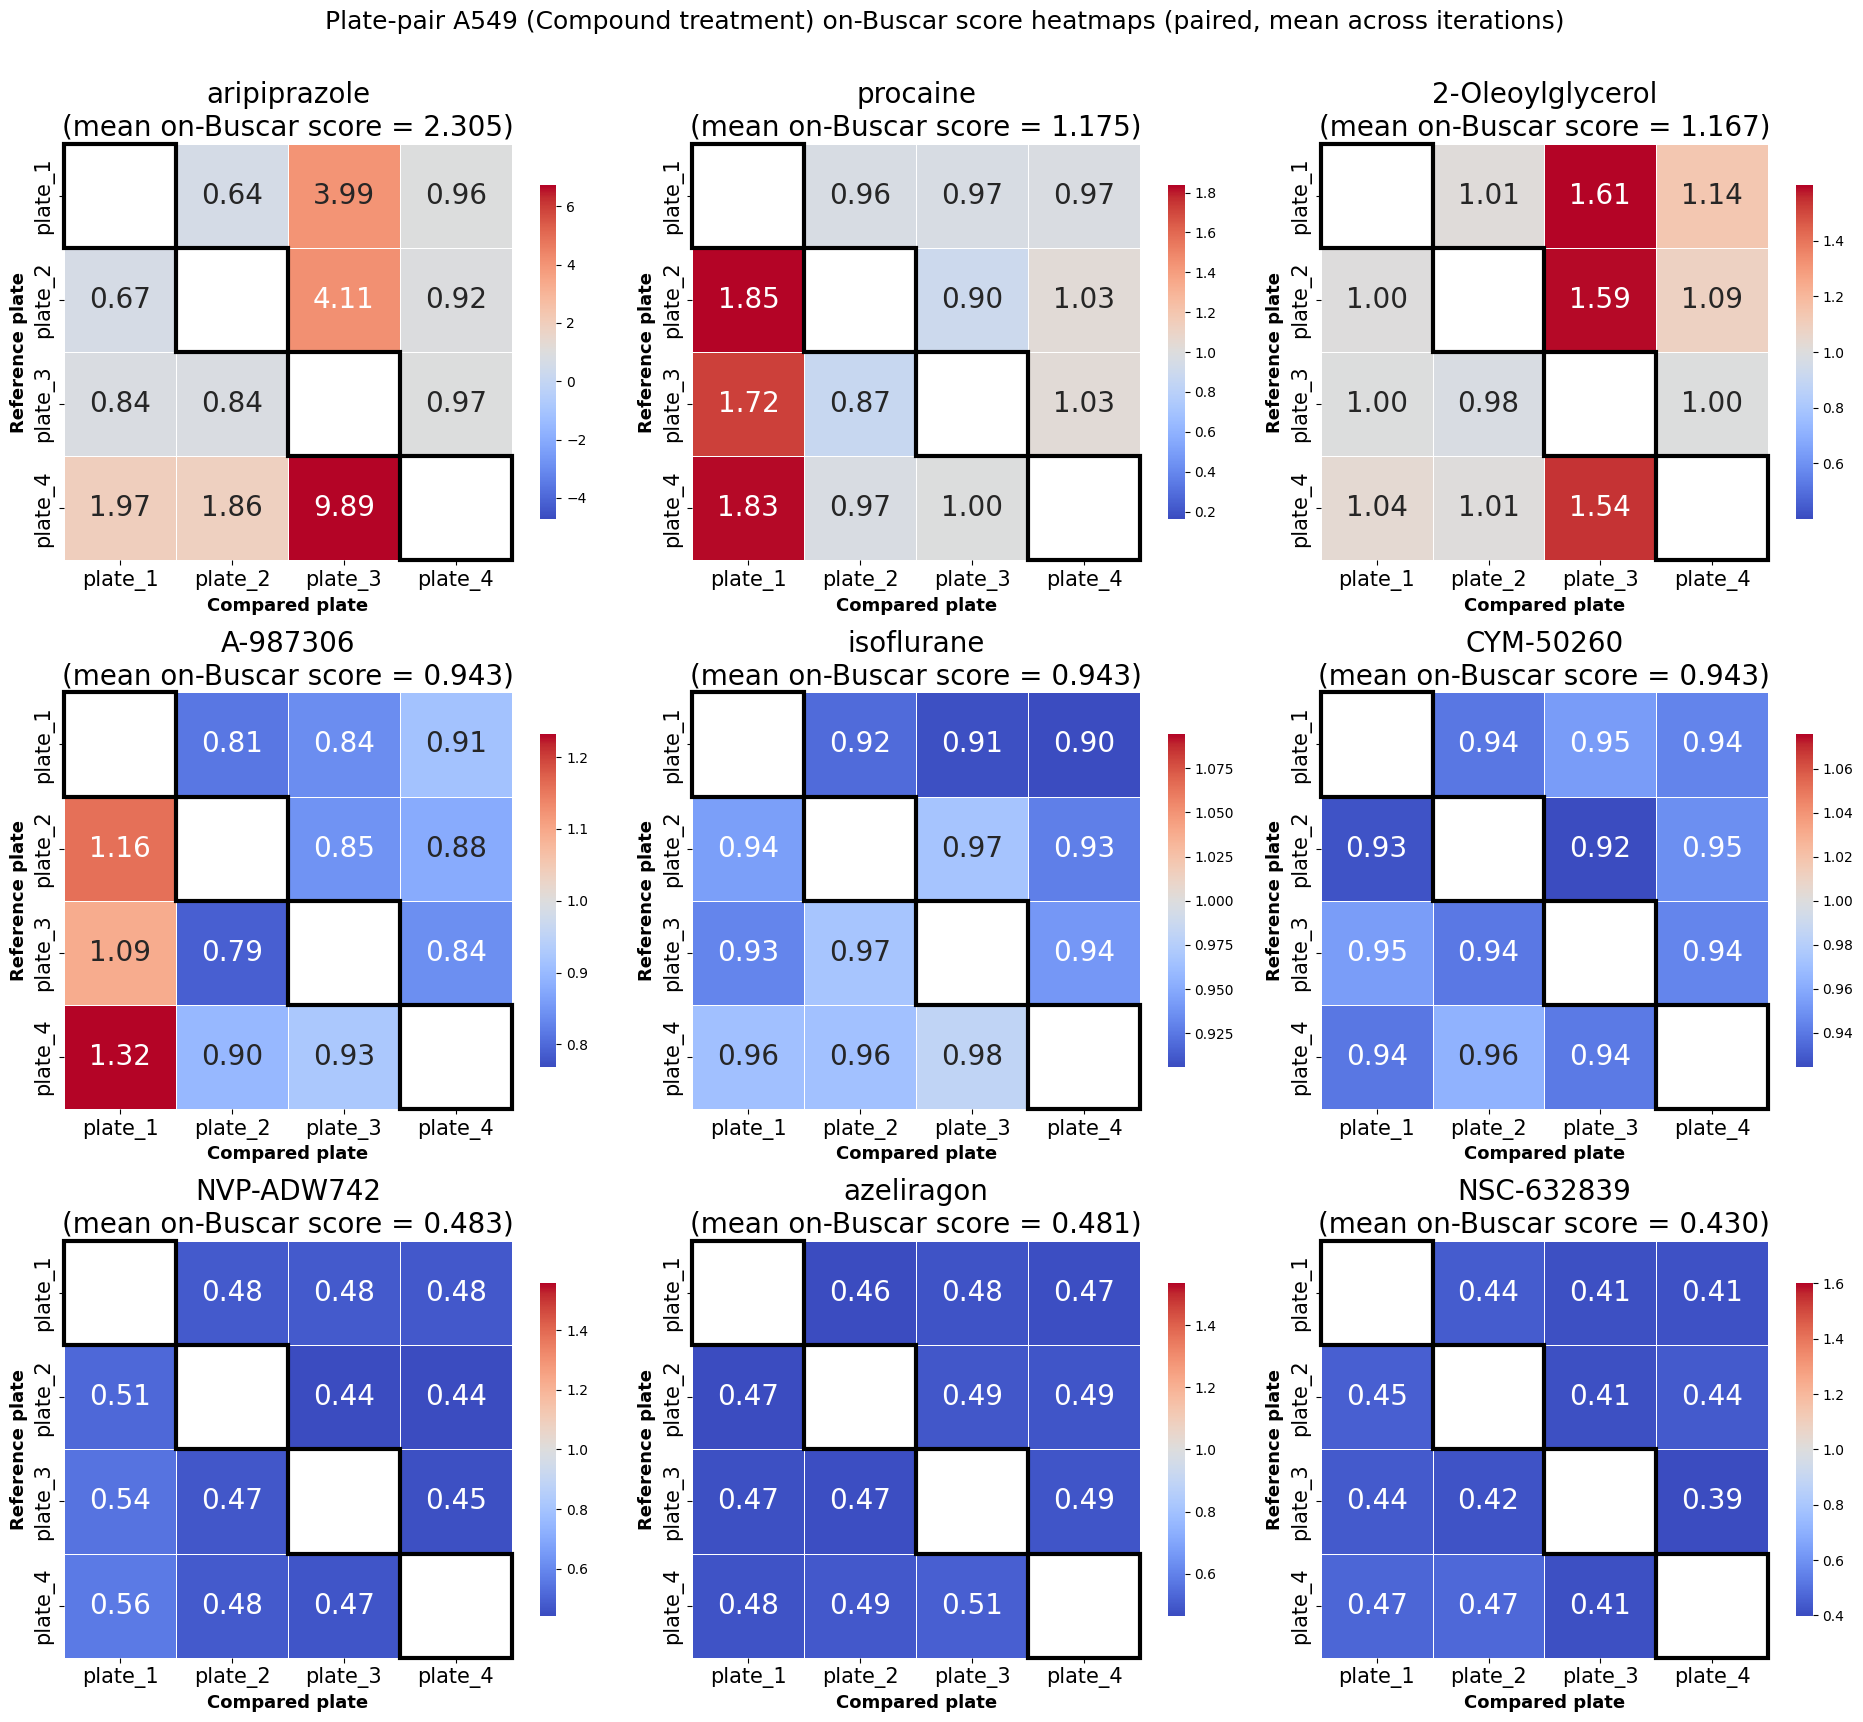

In [43]:
plot_plate_pair_heatmaps(
    a549_rep_trt_df,
    shuffled_a549_rep_trt_df,
    a549_agg_df,
    cell_type="A549 (Compound treatment)",
    replicate_matching_condition="paired",
    save_path=plot_output / "compound_a549_plate_pair_heatmaps_real.png",
)

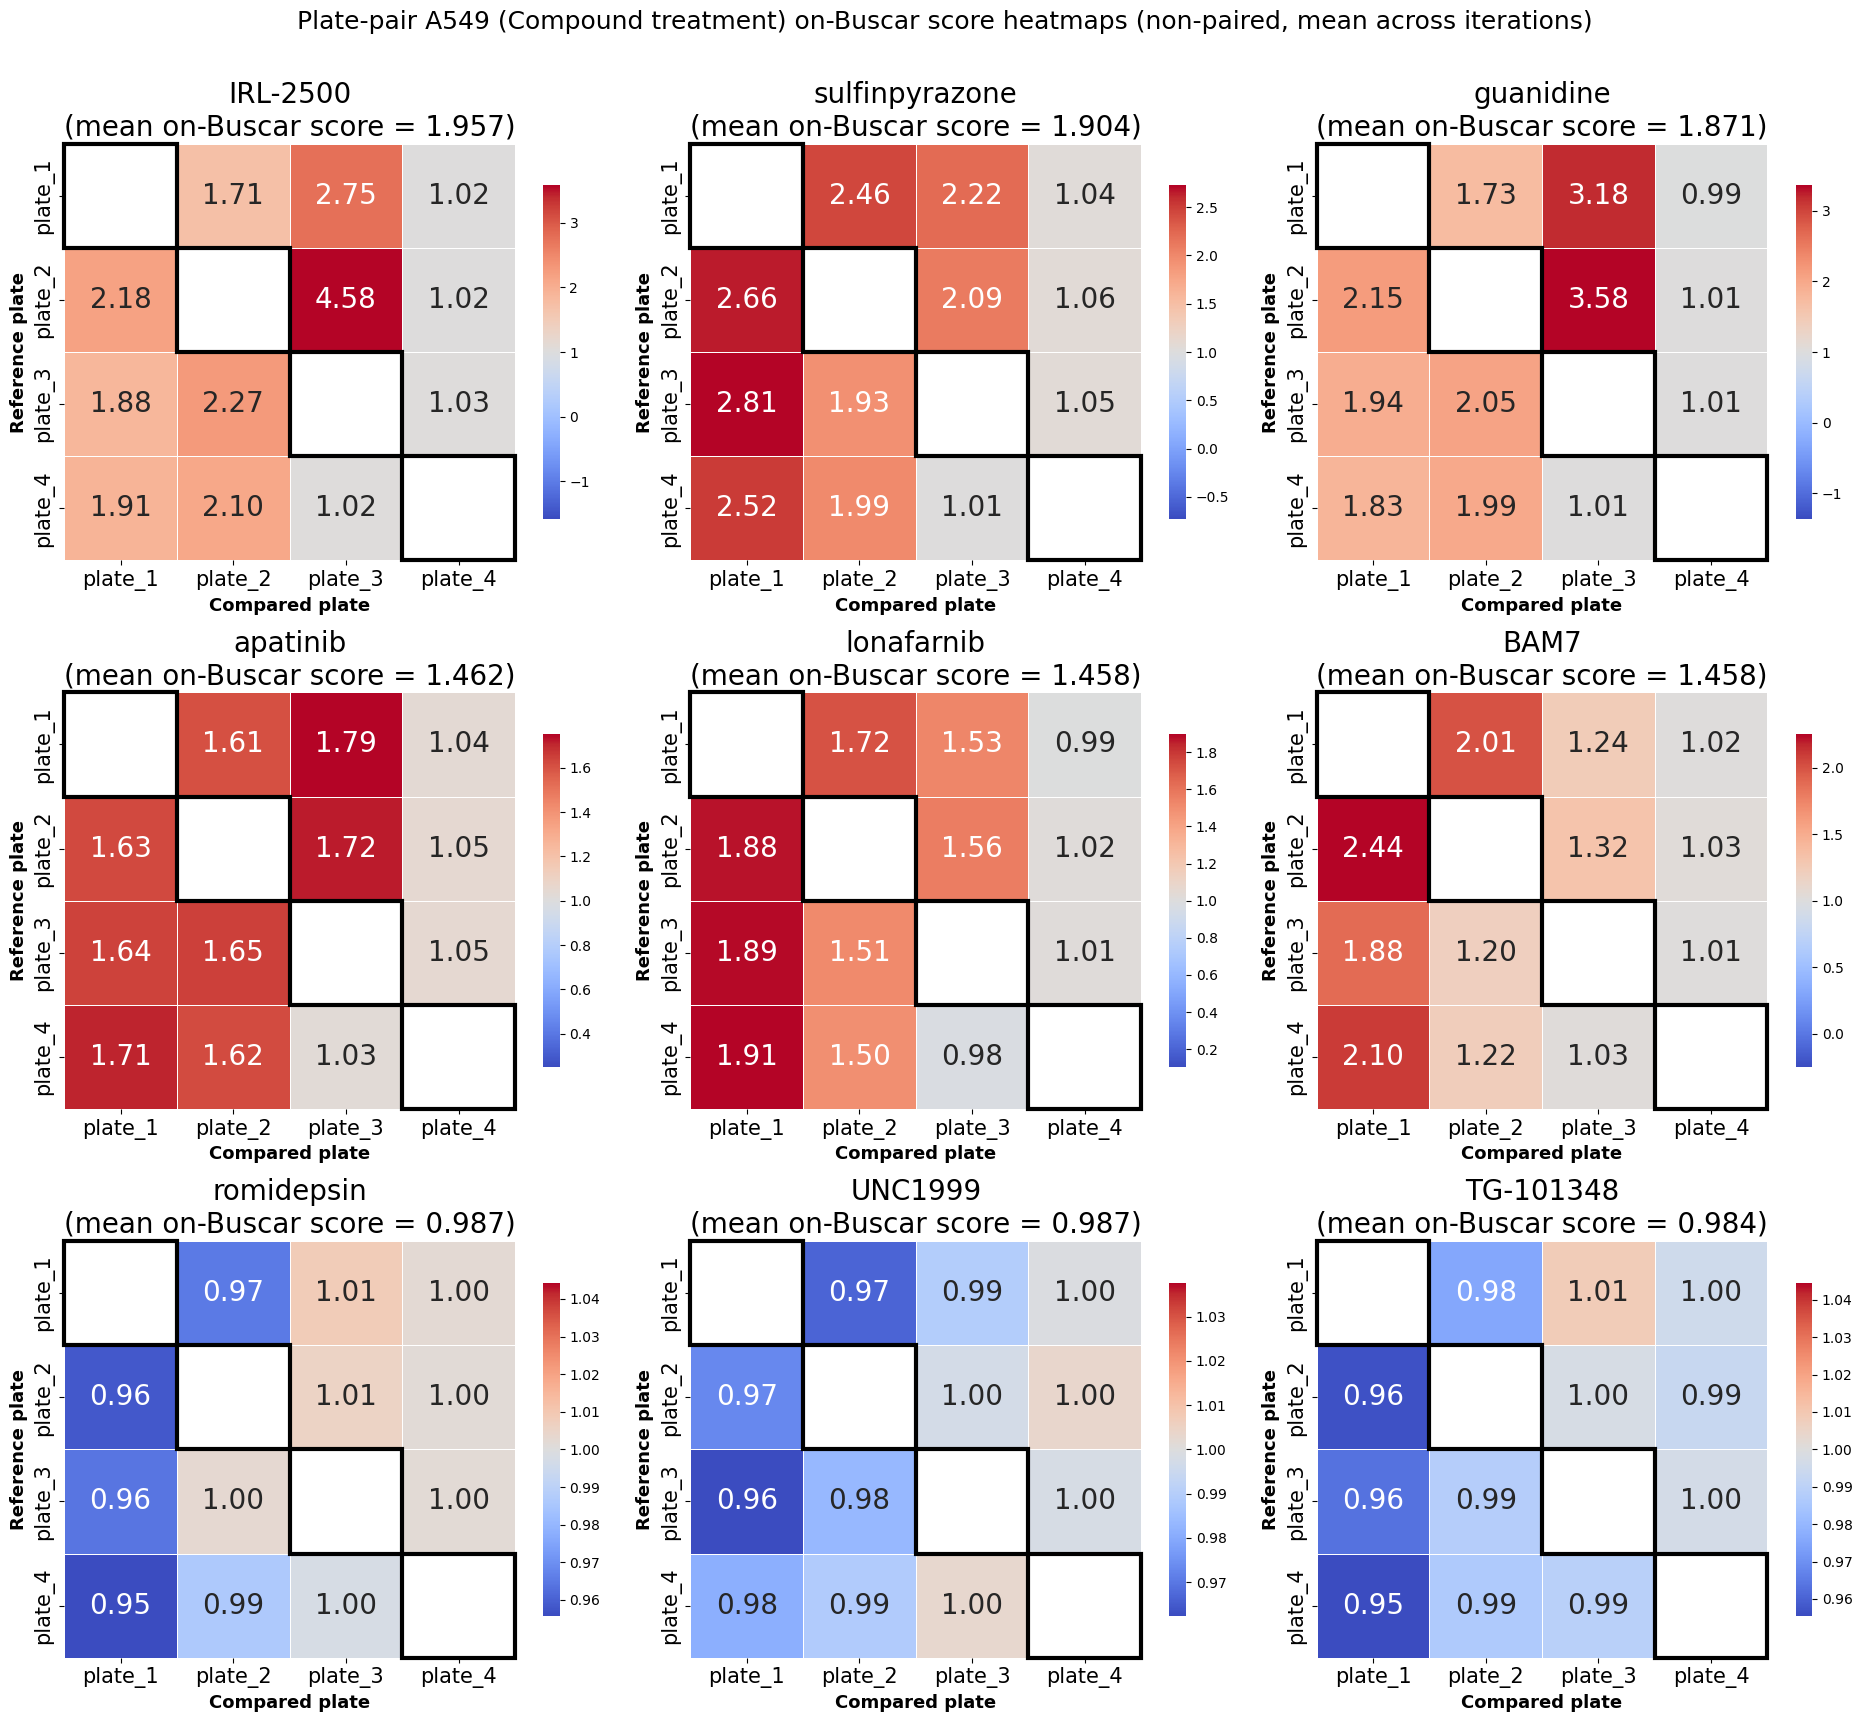

In [44]:
plot_plate_pair_heatmaps(
    a549_rep_trt_df,
    shuffled_a549_rep_trt_df,
    a549_agg_df,
    cell_type="A549 (Compound treatment)",
    replicate_matching_condition="non-paired",
    save_path=plot_output / "compound_a549_plate_pair_heatmaps_non_rep.png",
)

## Replicate analysis CRISPR plates

Assessing replicate consistency for CRISPR perturbations.


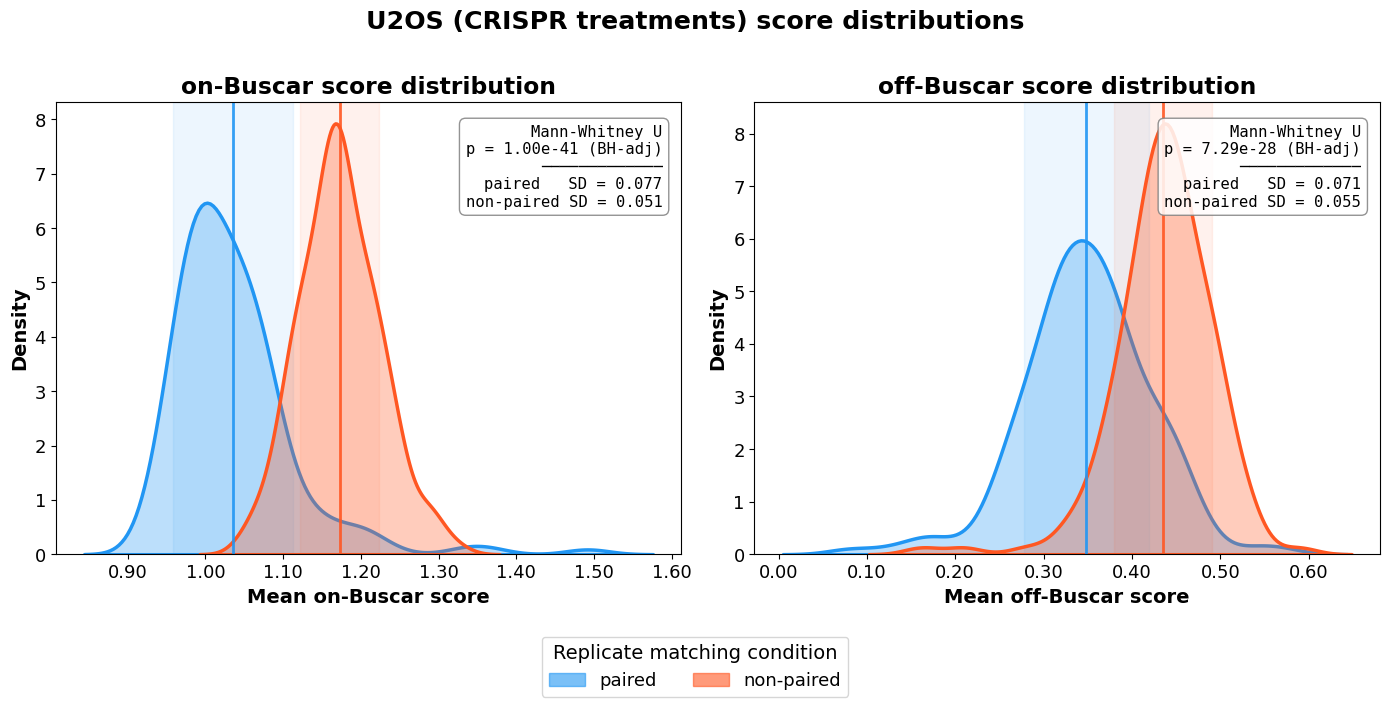

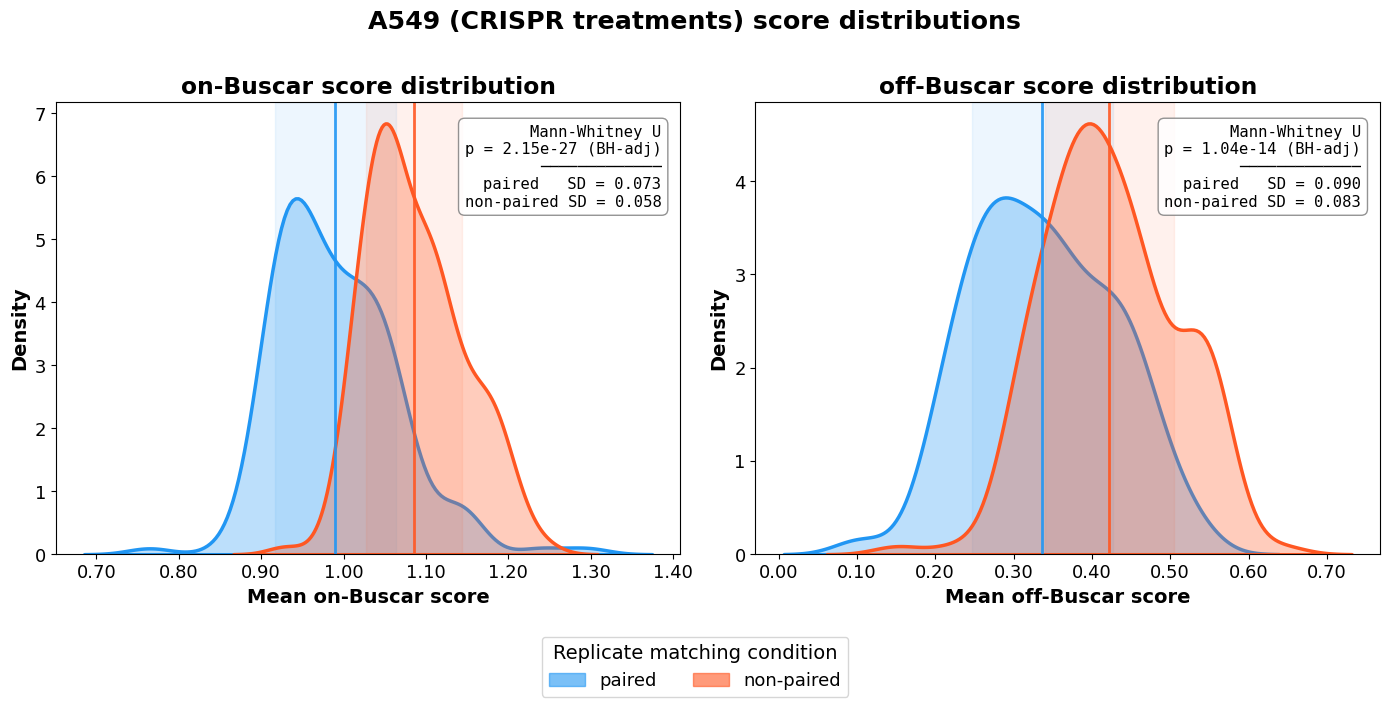

In [45]:
# U2OS CRISPR
u2os_crispr_cross_df, u2os_crispr_agg_df, u2os_crispr_real_agg, u2os_crispr_shuf_agg = (
    prepare_cross_data(u2os_rep_crispr_df, shuffled_u2os_rep_crispr_df)
)
u2os_crispr_stats_df = run_statistical_tests(u2os_crispr_real_agg, u2os_crispr_shuf_agg)
u2os_crispr_stats_df.write_csv(
    output_dir / "u2os_crispr_statistical_tests.csv", separator=","
)

plot_global_distributions(
    u2os_crispr_real_agg,
    u2os_crispr_shuf_agg,
    u2os_crispr_stats_df,
    cell_type="U2OS (CRISPR treatments)",
    save_path=plot_output / "crispr_u2os_global_score_distributions.png",
)

# A549 CRISPR
a549_crispr_cross_df, a549_crispr_agg_df, a549_crispr_real_agg, a549_crispr_shuf_agg = (
    prepare_cross_data(a549_rep_crispr_df, shuffled_a549_rep_crispr_df)
)
a549_crispr_stats_df = run_statistical_tests(a549_crispr_real_agg, a549_crispr_shuf_agg)
a549_crispr_stats_df.write_csv(
    output_dir / "a549_crispr_statistical_tests.csv", separator=","
)

plot_global_distributions(
    a549_crispr_real_agg,
    a549_crispr_shuf_agg,
    a549_crispr_stats_df,
    cell_type="A549 (CRISPR treatments)",
    save_path=plot_output / "crispr_a549_global_score_distributions.png",
)

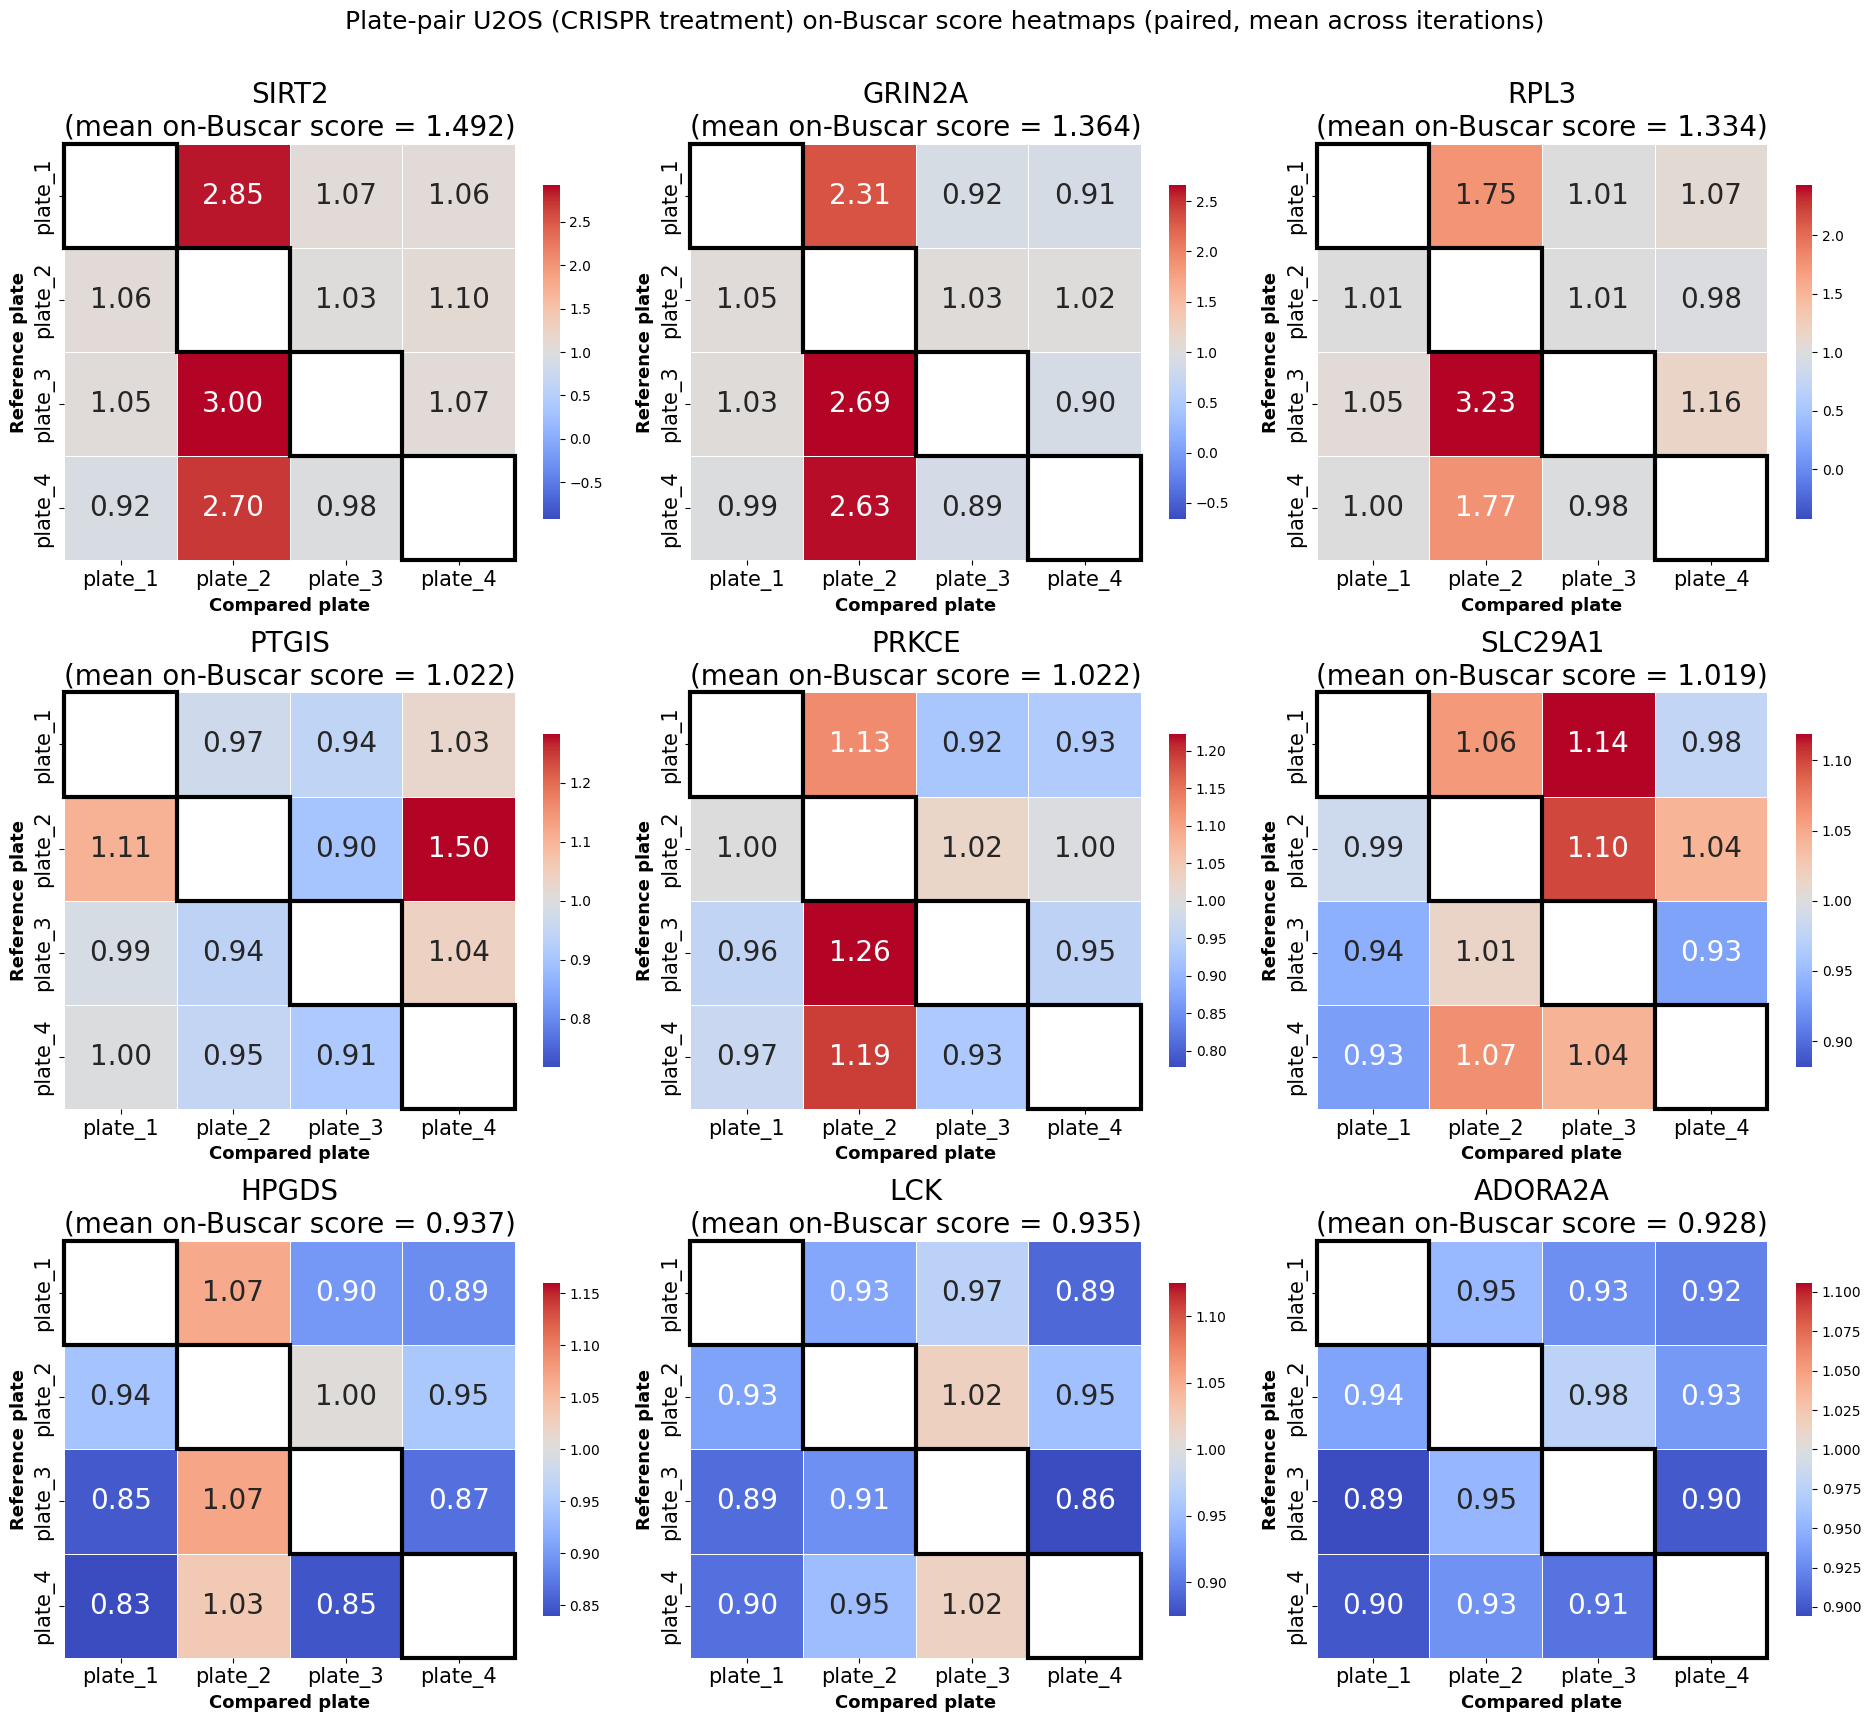

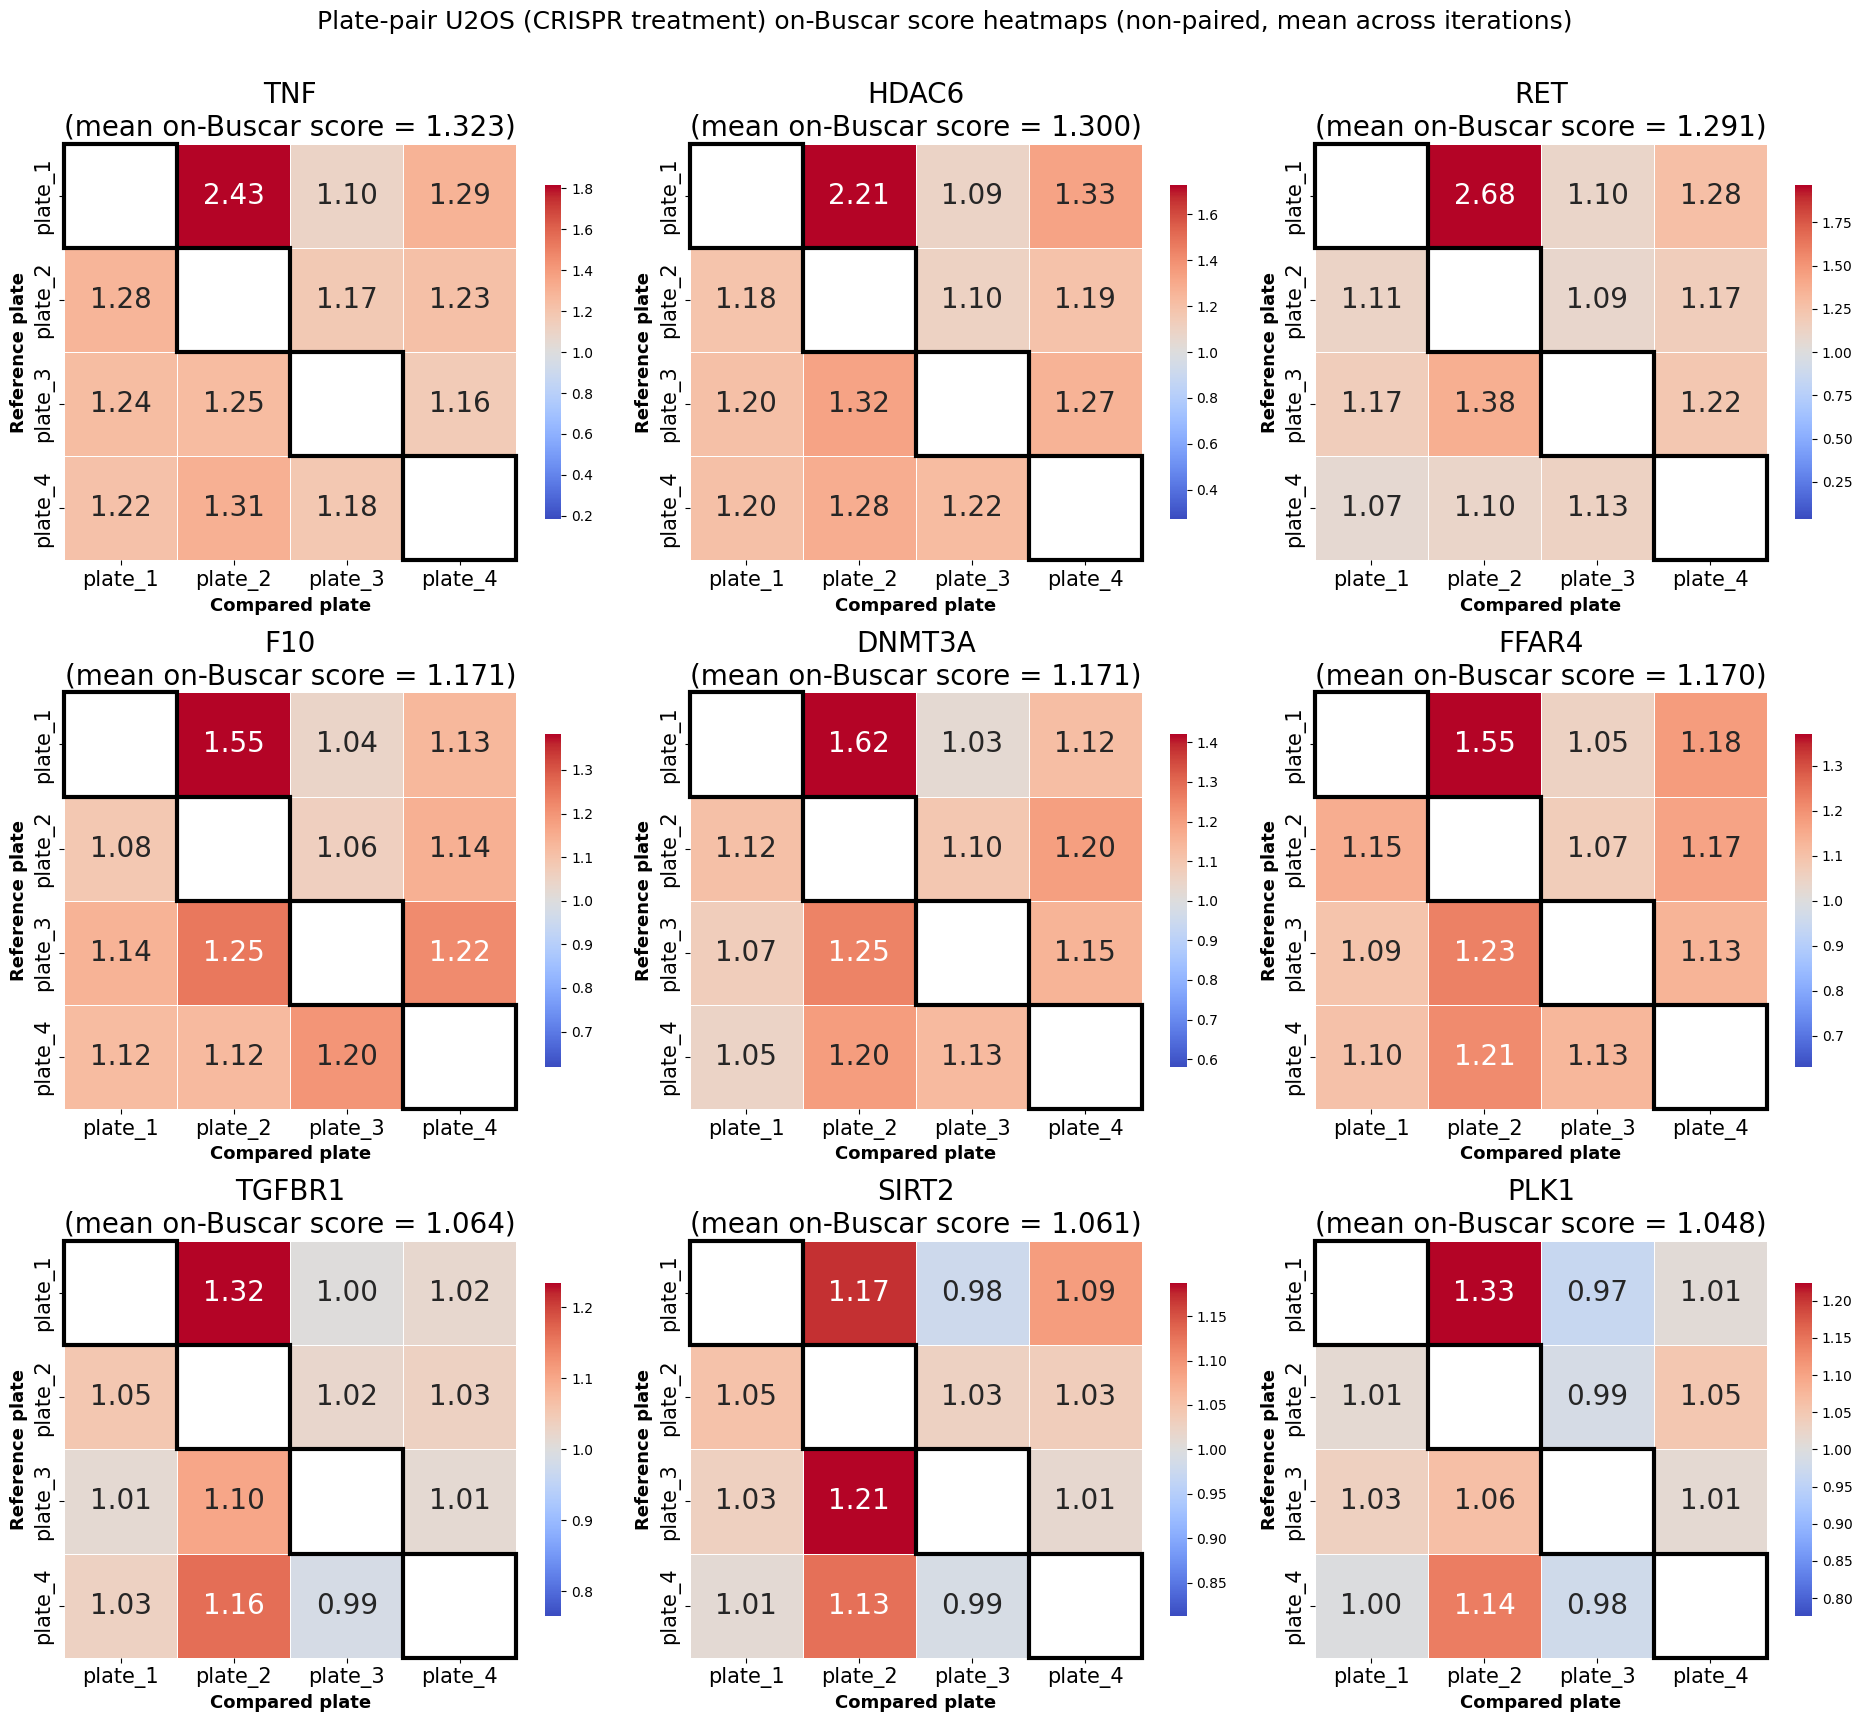

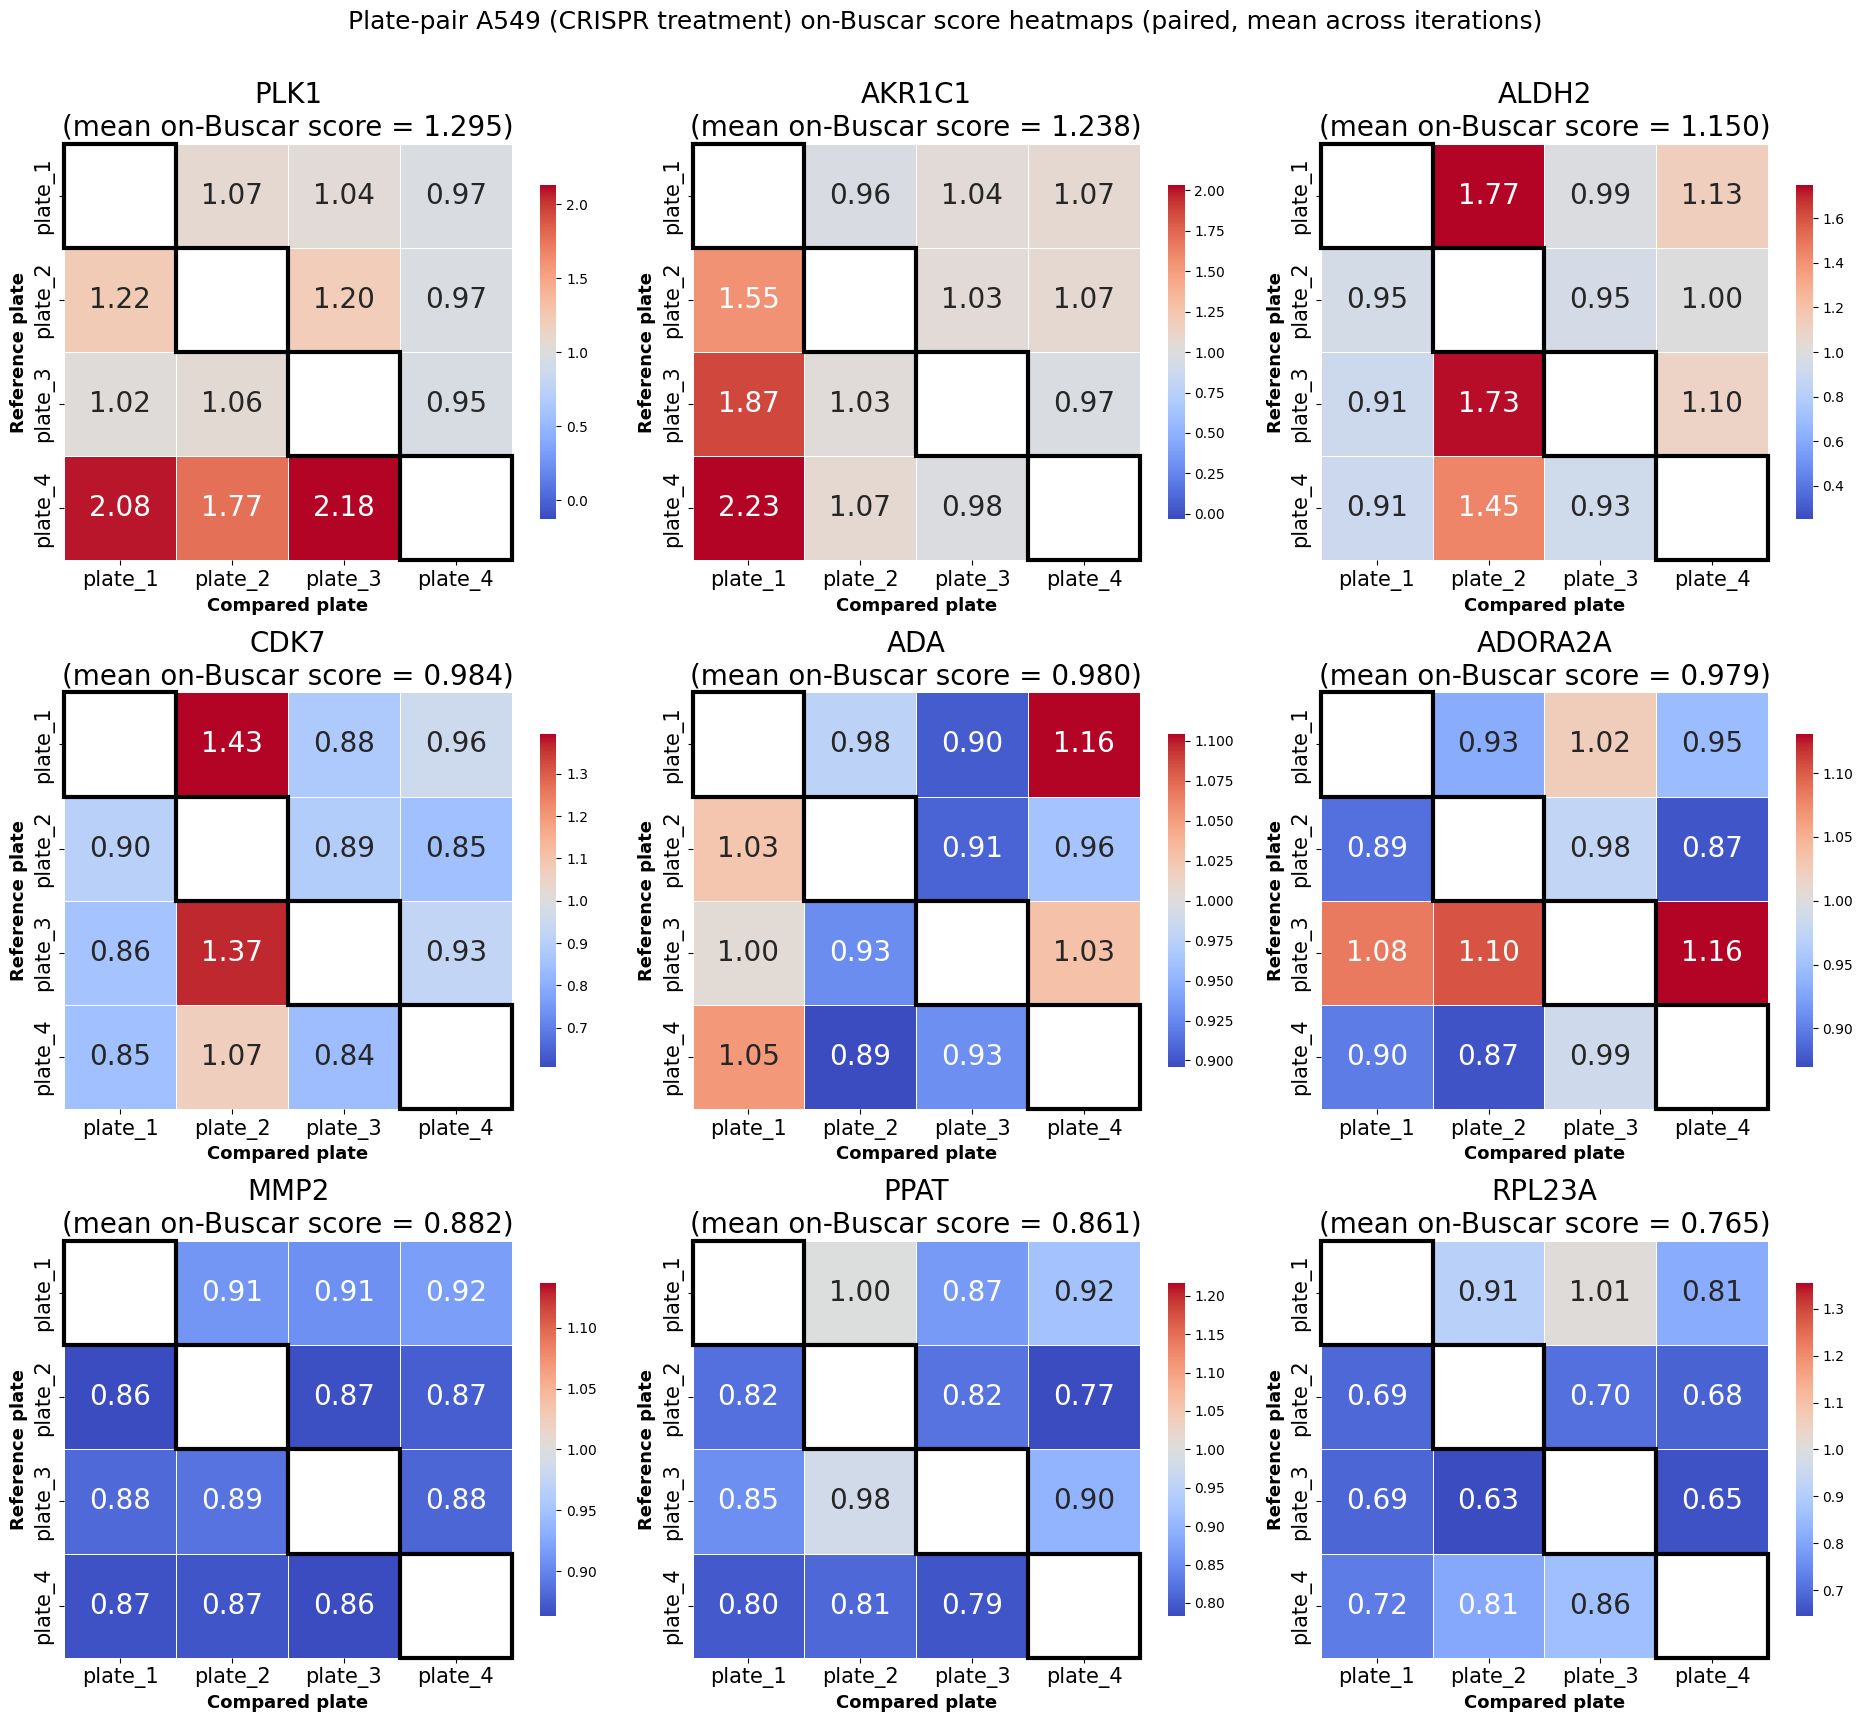

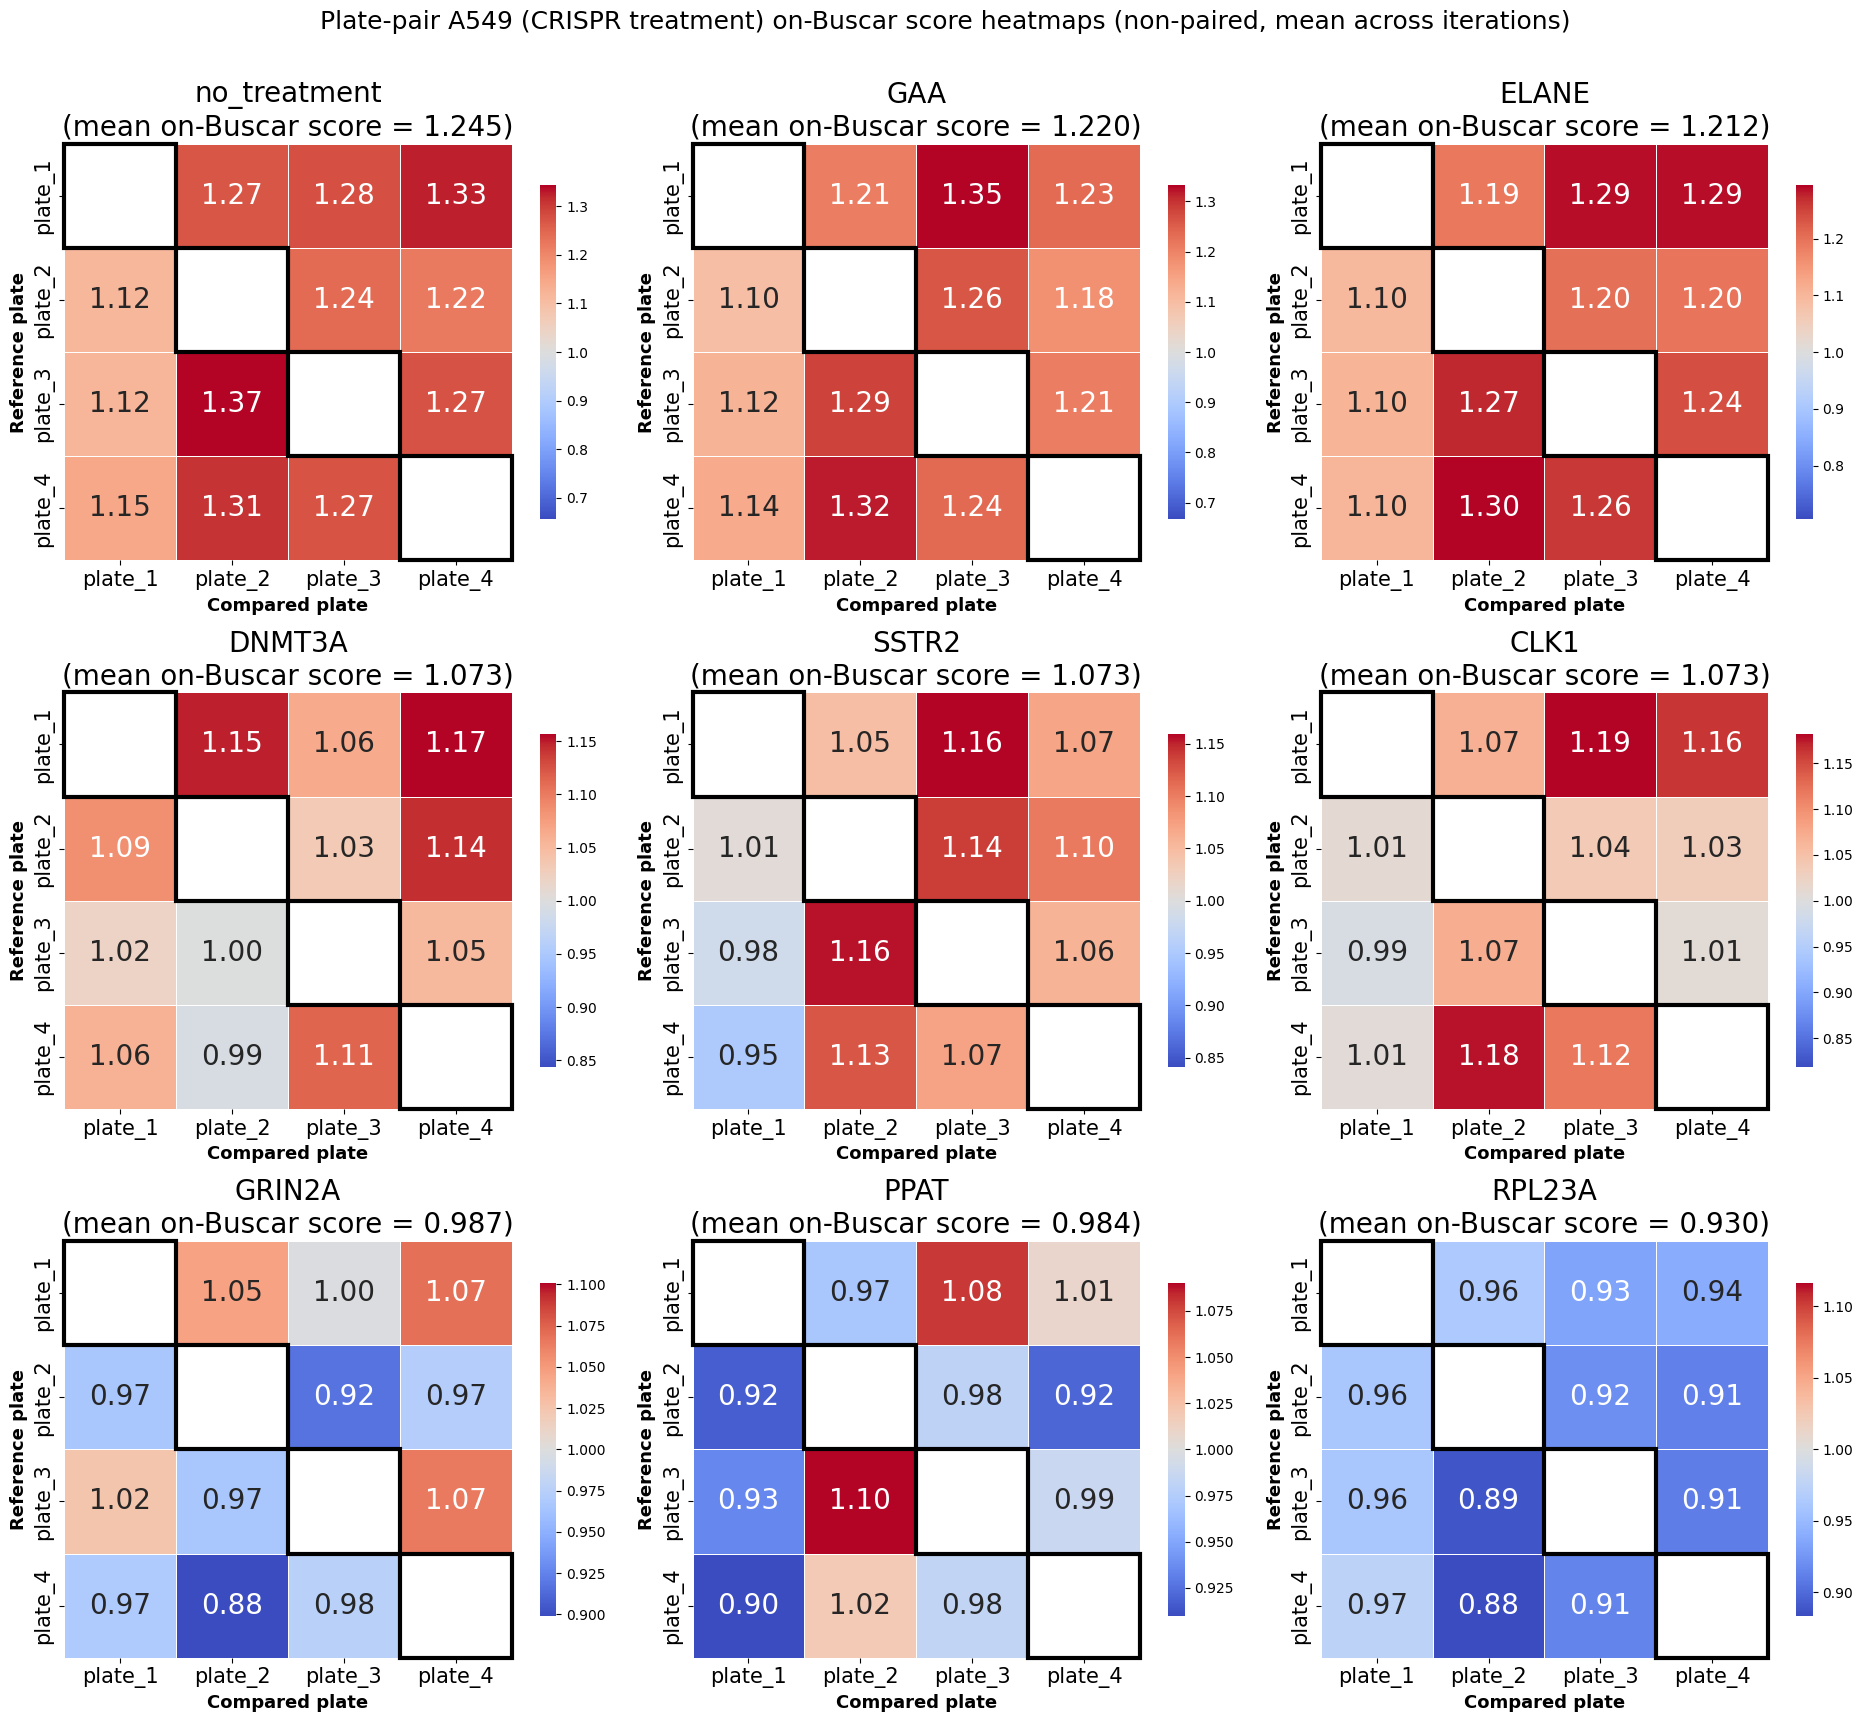

In [46]:
# Heatmaps for U2OS CRISPR
plot_plate_pair_heatmaps(
    u2os_rep_crispr_df,
    shuffled_u2os_rep_crispr_df,
    u2os_crispr_agg_df,
    cell_type="U2OS (CRISPR treatment)",
    replicate_matching_condition="paired",
    save_path=plot_output / "crispr_u2os_plate_pair_heatmaps_real.png",
)

plot_plate_pair_heatmaps(
    u2os_rep_crispr_df,
    shuffled_u2os_rep_crispr_df,
    u2os_crispr_agg_df,
    cell_type="U2OS (CRISPR treatment)",
    replicate_matching_condition="non-paired",
    save_path=plot_output / "crispr_u2os_plate_pair_heatmaps_non_rep.png",
)

# Heatmaps for A549 CRISPR
plot_plate_pair_heatmaps(
    a549_rep_crispr_df,
    shuffled_a549_rep_crispr_df,
    a549_crispr_agg_df,
    cell_type="A549 (CRISPR treatment)",
    replicate_matching_condition="paired",
    save_path=plot_output / "crispr_a549_plate_pair_heatmaps_real.png",
)

plot_plate_pair_heatmaps(
    a549_rep_crispr_df,
    shuffled_a549_rep_crispr_df,
    a549_crispr_agg_df,
    cell_type="A549 (CRISPR treatment)",
    replicate_matching_condition="non-paired",
    save_path=plot_output / "crispr_a549_plate_pair_heatmaps_non_rep.png",
)